## **OBJECTIVE**

A retail company tested a new store layout in Stores 77, 86, and 88 within the chips category from the beginning of February 2019 through the end of April 2019. The objective is to assess whether the layout change leads to a measurable improvement in sales performance compared to stores operating under the existing layout.

The analysis aims to quantify the impact of the trial by comparing trial stores against comparable control stores, and to provide a data-driven recommendation on whether the new layout should be rolled out more broadly.

The primary focus is on changes in:

* total sales revenue
* customer count
* transactions per customer

In [ ]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import t as t_dist


#Load Dataset
#Data is not included in the repository
#Placeholder code to load the dataset
DATA_PATH = "data/"
data  =pd.read_csv(DATA_PATH + "merged_data.csv")

/kaggle/input/datasets/dolapooyetunbi/cleaned-chip-data/merged_data.csv


## **HYPOTHESIS**

The introduction of the new store layout has no measurable impact on store performance in the trial stores compared to their matched control stores.

* **H0 (Null Hypothesis):** The store layout change has no effect on total sales revenue, customer count, or transactions per customer.
* **H1 (Alternative Hypothesis):** The store layout change leads to improvements in one or more of the key performance metrics relative to matched control stores.


## **Evaluation Metrics**

The impact of the trial is evaluated using three primary performance metrics:

* **Total sales revenue:** change in overall sales during the trial period
* **Customer count:** change in number of unique customers
* **Transactions per customer:** change in purchase frequency per customer

A successful outcome is defined as a **consistent positive uplift in these key performance metrics for the trial stores relative to their matched control stores during the trial period, compared to the pre-trial baseline**.

In [2]:
#Preview dataset
data.head(3)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NCC,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget


In [3]:
#Gain insight into the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              246740 non-null  object 
 1   STORE_NBR         246740 non-null  int64  
 2   LYLTY_CARD_NBR    246740 non-null  int64  
 3   TXN_ID            246740 non-null  int64  
 4   PROD_NBR          246740 non-null  int64  
 5   PROD_NAME         246740 non-null  object 
 6   PROD_QTY          246740 non-null  int64  
 7   TOT_SALES         246740 non-null  float64
 8   PACK_SIZE         246740 non-null  int64  
 9   BRAND             246740 non-null  object 
 10  LIFESTAGE         246740 non-null  object 
 11  PREMIUM_CUSTOMER  246740 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 22.6+ MB


In [4]:
# verify store pool size
print(data['STORE_NBR'].nunique())

271


In [5]:
##Add a new column for month in yyyymm format
data['YEARMONTH'] = pd.to_datetime(data['DATE']).dt.strftime('%Y%m').astype(int)
data.head(3)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NCC,YOUNG SINGLES/COUPLES,Premium,201810
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget,201905
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget,201905


In [6]:
# group by store and month
extended_summary = data.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    total_sales=('TOT_SALES', 'sum'),
    num_customers=('LYLTY_CARD_NBR', 'nunique'),
    num_transactions=('TXN_ID', 'nunique'),
    total_chips=('PROD_QTY', 'sum')
).reset_index()

# derived metrics
extended_summary['txn_per_customer'] = extended_summary['num_transactions'] / extended_summary['num_customers']
extended_summary['chips_per_customer'] = extended_summary['total_chips'] / extended_summary['num_customers']
extended_summary['avg_price_per_unit'] = extended_summary['total_sales'] / extended_summary['total_chips']

extended_summary = extended_summary.replace([float('inf'), -float('inf')], 0).fillna(0)

print(extended_summary)

      STORE_NBR  YEARMONTH  total_sales  num_customers  num_transactions  \
0             1     201807        188.9             47                49   
1             1     201808        168.4             41                41   
2             1     201809        268.1             57                59   
3             1     201810        175.4             39                40   
4             1     201811        184.8             44                45   
...         ...        ...          ...            ...               ...   
3160        272     201902        385.3             44                47   
3161        272     201903        421.9             48                51   
3162        272     201904        445.1             54                55   
3163        272     201905        314.6             34                40   
3164        272     201906        301.9             33                36   

      total_chips  txn_per_customer  chips_per_customer  avg_price_per_unit  
0        

In [7]:
#Check the structure of the summary dataframe
extended_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3165 entries, 0 to 3164
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   STORE_NBR           3165 non-null   int64  
 1   YEARMONTH           3165 non-null   int64  
 2   total_sales         3165 non-null   float64
 3   num_customers       3165 non-null   int64  
 4   num_transactions    3165 non-null   int64  
 5   total_chips         3165 non-null   int64  
 6   txn_per_customer    3165 non-null   float64
 7   chips_per_customer  3165 non-null   float64
 8   avg_price_per_unit  3165 non-null   float64
dtypes: float64(4), int64(5)
memory usage: 222.7 KB


In [8]:
#Select relevant columns for further analysis
summary = extended_summary[['STORE_NBR', 'YEARMONTH', 'total_sales', 'num_customers', 'txn_per_customer']]

In [9]:
summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3165 entries, 0 to 3164
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   STORE_NBR         3165 non-null   int64  
 1   YEARMONTH         3165 non-null   int64  
 2   total_sales       3165 non-null   float64
 3   num_customers     3165 non-null   int64  
 4   txn_per_customer  3165 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 123.8 KB


In [10]:
# Filter to the pre-trial period and stores with full observation periods
pre_trial = summary[summary['YEARMONTH'] < 201902]
pre_trial.head(3)

,STORE_NBR,YEARMONTH,total_sales,num_customers,txn_per_customer
0,1,201807,188.9,47,1.042553
1,1,201808,168.4,41,1.000000
2,1,201809,268.1,57,1.035088


In [11]:
pre_trial.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1846 entries, 0 to 3159
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   STORE_NBR         1846 non-null   int64  
 1   YEARMONTH         1846 non-null   int64  
 2   total_sales       1846 non-null   float64
 3   num_customers     1846 non-null   int64  
 4   txn_per_customer  1846 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 86.5 KB


In [12]:
# number of unique months in pre-trial
num_months = pre_trial['YEARMONTH'].nunique()
print(f'Number of unique months in pre-trial period: {num_months}')

Number of unique months in pre-trial period: 7


In [13]:
# count months per store
store_month_counts = pre_trial.groupby('STORE_NBR')['YEARMONTH'].nunique()

# stores with full observation
valid_stores = store_month_counts[store_month_counts == num_months].index

# filter
pre_trial_full = pre_trial[pre_trial['STORE_NBR'].isin(valid_stores)]
pre_trial_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1820 entries, 0 to 3159
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   STORE_NBR         1820 non-null   int64  
 1   YEARMONTH         1820 non-null   int64  
 2   total_sales       1820 non-null   float64
 3   num_customers     1820 non-null   int64  
 4   txn_per_customer  1820 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 85.3 KB


In [14]:
#number of unique stores in pre-trial with full observation
print('Number of unique stores in pre-trial with full observation:', pre_trial_full['STORE_NBR'].nunique())

Number of unique stores in pre-trial with full observation: 260


Given high data completeness (~96%), we restricted control candidates to stores with full pre-trial coverage to ensure stable trend comparison and robust similarity matching

In [15]:
# function to calculate correlation with safe guards
def safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # remove NaNs (just in case)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    # need at least 2 points
    if len(x) < 2:
        return 0.0

    # zero variance guard
    if np.isclose(x.std(), 0) or np.isclose(y.std(), 0):
        return 0.0

    # centered vectors
    x_centered = x - x.mean()
    y_centered = y - y.mean()

    numerator = np.sum(x_centered * y_centered)
    denominator = np.sqrt(np.sum(x_centered**2) * np.sum(y_centered**2))

    if denominator == 0:
        return 0.0

    return numerator / denominator

In [16]:
# Function to calculate correlation of a metric with the trial store across all stores
def calc_corr(input_table, metric, trial_store):

    pivot = input_table.pivot(
        index='YEARMONTH',
        columns='STORE_NBR',
        values=metric
    )

    # ensure no NaNs (important)
    pivot = pivot.fillna(0)

    trial_series = pivot[trial_store].values

    results = []

    for store in pivot.columns:
        if store == trial_store:
            continue

        corr = safe_corr(trial_series, pivot[store].values)

        results.append((trial_store, store, corr))

    return pd.DataFrame(
        results,
        columns=['trial_store', 'control_store', 'correlation']
    )

In [17]:
print(calc_corr(pre_trial_full, 'total_sales', 77))

     trial_store  control_store  correlation
0             77              1    -0.005382
1             77              2    -0.251183
2             77              3     0.660447
3             77              4    -0.347846
4             77              5    -0.139048
..           ...            ...          ...
254           77            268     0.395460
255           77            269    -0.466370
256           77            270     0.274854
257           77            271     0.195190
258           77            272    -0.179647

[259 rows x 3 columns]


In [18]:
# Calculate Root Mean Squared Error (RMSE) between trial store
# and all candidate control stores, then normalize by the
# mean of the trial store metric.

def calc_nrmse(input_table, metric, trial_store):

    pivot = input_table.pivot(
        index='YEARMONTH',
        columns='STORE_NBR',
        values=metric
    )

    trial_series = pivot[trial_store]

    results = []

    for store in pivot.columns:

        if store == trial_store:
            continue

        candidate_series = pivot[store]

        # keep only valid overlapping months
        valid = trial_series.notna() & candidate_series.notna()

        trial_valid = trial_series[valid]
        candidate_valid = candidate_series[valid]

        diff = trial_valid - candidate_valid

        # Root Mean Squared Error
        rmse = np.sqrt(np.mean(diff ** 2))

        # Normalize by mean of trial store
        nrmse = rmse / (trial_valid.mean() + 1e-9)

        # Convert to similarity measure (1 means identical, 0 means very different)
        nrmse_sim = 1 - nrmse

        results.append({
            'trial_store': trial_store,
            'control_store': store,
            'nrmse_score': nrmse_sim
        })

    return pd.DataFrame(results).sort_values('nrmse_score', ascending=False).reset_index(drop=True)

In [19]:
print(calc_nrmse(pre_trial_full, 'total_sales', 77))

     trial_store  control_store  nrmse_score
0             77            233     0.904698
1             77            188     0.867515
2             77             50     0.847855
3             77             53     0.831307
4             77            205     0.829658
..           ...            ...          ...
254           77             58    -3.443054
255           77            165    -3.501773
256           77             88    -3.545570
257           77            237    -3.596203
258           77            226    -4.088459

[259 rows x 3 columns]


In [20]:
# combine correlation and nrmse into a single score with a weight parameter
def combine_measure(weight, input_table, metric, trial_store):

    corr_df = calc_corr(
        input_table,
        metric,
        trial_store
    )

    nrmse_df = calc_nrmse(
        input_table,
        metric,
        trial_store
    )

    combined = corr_df.merge(
        nrmse_df,
        on=['trial_store', 'control_store']
    )

    combined['final_score'] = (
        weight * combined['correlation'] +
        (1 - weight) * combined['nrmse_score']
    )

    return combined

In [21]:
print(combine_measure(0.5, pre_trial_full, 'total_sales', 77))

     trial_store  control_store  correlation  nrmse_score  final_score
0             77              1    -0.005382     0.724406     0.359512
1             77              2    -0.251183     0.620941     0.184879
2             77              3     0.660447    -2.511015    -0.925284
3             77              4    -0.347846    -3.404556    -1.876201
4             77              5    -0.139048    -1.353173    -0.746110
..           ...            ...          ...          ...          ...
254           77            268     0.395460     0.791043     0.593252
255           77            269    -0.466370    -1.952590    -1.209480
256           77            270     0.274854    -1.922673    -0.823909
257           77            271     0.195190    -1.326304    -0.565557
258           77            272    -0.179647     0.373954     0.097153

[259 rows x 5 columns]


In [22]:
# final control score function that combines multiple metrics with weights
def final_control_score(w1, w2, w3, metric_weight, input_table, trial_store):

    metrics = ['total_sales', 'num_customers', 'txn_per_customer']
    weights = [w1, w2, w3]

    # normalize weights safely
    total_w = sum(weights)
    weights = [w / total_w for w in weights]

    score_tables = []

    # build similarity tables
    for metric in metrics:
        sim = combine_measure(metric_weight, input_table, metric, trial_store)
        sim = sim[['control_store', 'final_score']].rename(
            columns={'final_score': metric}
        )
        score_tables.append(sim)

    # vectorized merge (reduce pattern)
    from functools import reduce

    final_scores = reduce(
        lambda left, right: pd.merge(left, right, on='control_store'),
        score_tables
    )

    # vectorized weighted sum (no manual score columns)
    metric_matrix = final_scores[metrics].to_numpy()
    weight_vector = np.array(weights)

    final_scores['weighted_final_score'] = metric_matrix @ weight_vector

    return final_scores.sort_values('weighted_final_score', ascending=False)

In [23]:
#similarity scores for reference stores
store_77 = final_control_score(1/3, 1/3, 1/3, 0.5, pre_trial_full, 77)
store_86 = final_control_score(1/3, 1/3, 1/3, 0.5, pre_trial_full, 86)
store_88 = final_control_score(1/3, 1/3, 1/3, 0.5, pre_trial_full, 88)

In [24]:
store_77.head(3)

,control_store,total_sales,num_customers,txn_per_customer,weighted_final_score
220,233,0.939171,0.961862,0.368802,0.756612
112,121,0.611915,0.630616,0.785629,0.676054
136,145,0.408711,0.701940,0.898740,0.669797


In [25]:
store_77.info()

<class 'pandas.core.frame.DataFrame'>
Index: 259 entries, 220 to 3
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   control_store         259 non-null    int64  
 1   total_sales           259 non-null    float64
 2   num_customers         259 non-null    float64
 3   txn_per_customer      259 non-null    float64
 4   weighted_final_score  259 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 12.1 KB


In [26]:
store_86.head(3)

,control_store,total_sales,num_customers,txn_per_customer,weighted_final_score
129,138,0.866178,0.775213,0.807000,0.816130
106,114,0.835574,0.900733,0.629624,0.788644
255,269,0.823741,0.614408,0.874956,0.771035


In [27]:
store_86.info()

<class 'pandas.core.frame.DataFrame'>
Index: 259 entries, 129 to 111
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   control_store         259 non-null    int64  
 1   total_sales           259 non-null    float64
 2   num_customers         259 non-null    float64
 3   txn_per_customer      259 non-null    float64
 4   weighted_final_score  259 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 12.1 KB


In [28]:
store_88.head(3)

,control_store,total_sales,num_customers,txn_per_customer,weighted_final_score
191,201,0.677133,0.600320,0.795870,0.691107
114,123,0.619074,0.762910,0.683856,0.688613
98,106,0.651880,0.553735,0.833191,0.679602


In [29]:
store_88.info()

<class 'pandas.core.frame.DataFrame'>
Index: 259 entries, 191 to 250
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   control_store         259 non-null    int64  
 1   total_sales           259 non-null    float64
 2   num_customers         259 non-null    float64
 3   txn_per_customer      259 non-null    float64
 4   weighted_final_score  259 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 12.1 KB


## **Control Store Matching (Scoring Framework)**

To select matched control stores, we construct a composite similarity framework that captures both trend similarity and magnitude closeness across key performance metrics.

* Correlation (trend similarity): We define a correlation function with a safeguard against zero variance to ensure numerical stability. This measures how closely trial and control stores move together over time.
* Normalized RMSE (magnitude difference): To capture differences in scale, we compute a Root Mean Squared Error between trial and control series, normalized by the mean of the trial store:
    * This produces a scale-independent error measure
    * It is then transformed into a similarity score on a 0–1 scale, where:
        * 1 = identical behavior
        * 0 = highly dissimilar behavior

**Combined metric per feature**

For each metric (e.g., total sales, number of customers, transactions per customer):

We combine:
* correlation (trend alignment)
* normalized RMSE similarity (magnitude alignment)

This yields a single combined similarity score per metric

**Weighted final score**

The final control score is computed as the average of combined similarity scores across all metrics, ensuring balanced weighting across dimensions of store performance.

## **Control Store Selection Results**

Based on the final ranking:

* Trial Store 77 has Matched Control Store 233
    * Final score: 0.7566
    * Strong alignment in sales and customer metrics
    * Slight mismatch in transactions per customer, offset by strong overall alignment
* Trial Store 86 has Matched Control Store 138
    * Final score: 0.8161
    * High overall similarity across all metrics
* Trial Store 88 has Matched Control Store 201
    * Final score: 0.6911
    * Moderate similarity, with some divergence in transaction behavior

In [30]:

def matched_table(measure_over_time, trial_store, matched_store):

    over_time = measure_over_time.copy()

    # label store types
    over_time['store_type'] = over_time['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store
        else 'Control' if x == matched_store
        else 'Other stores'
    )
    
    # convert to date
    over_time['TransactionMonth'] = pd.to_datetime(
        over_time['YEARMONTH'].astype(str) + '01',
        format='%Y%m%d'
    )
    over_time = over_time[over_time['store_type'].isin(['Trial', 'Control'])]

    over_time = over_time[['YEARMONTH', 'TransactionMonth', 'STORE_NBR', 'store_type', 'total_sales', 'num_customers', 'txn_per_customer']]
    return over_time

In [31]:
print(matched_table(pre_trial, 77, store_77['control_store'].iloc[0]))

      YEARMONTH TransactionMonth  STORE_NBR store_type  total_sales  \
880      201807       2018-07-01         77      Trial        268.4   
881      201808       2018-08-01         77      Trial        247.5   
882      201809       2018-09-01         77      Trial        216.8   
883      201810       2018-10-01         77      Trial        194.3   
884      201811       2018-11-01         77      Trial        224.9   
885      201812       2018-12-01         77      Trial        255.2   
886      201901       2019-01-01         77      Trial        188.4   
2695     201807       2018-07-01        233    Control        271.2   
2696     201808       2018-08-01        233    Control        260.7   
2697     201809       2018-09-01        233    Control        220.9   
2698     201810       2018-10-01        233    Control        159.3   
2699     201811       2018-11-01        233    Control        206.5   
2700     201812       2018-12-01        233    Control        265.4   
2701  

In [32]:
matched_77 = matched_table(pre_trial, 77, store_77['control_store'].iloc[0])
matched_86 = matched_table(pre_trial, 86, store_86['control_store'].iloc[0])
matched_88 = matched_table(pre_trial, 88, store_88['control_store'].iloc[0])

In [33]:
matched_88.head(10)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer
1001,201807,2018-07-01,88,Trial,1218.2,124,1.161290
1002,201808,2018-08-01,88,Trial,1242.2,125,1.200000
1003,201809,2018-09-01,88,Trial,1361.8,121,1.247934
1004,201810,2018-10-01,88,Trial,1270.8,120,1.225000
1005,201811,2018-11-01,88,Trial,1311.4,123,1.211382
1006,201812,2018-12-01,88,Trial,1213.0,120,1.141667
1007,201901,2019-01-01,88,Trial,1215.4,115,1.217391
2334,201807,2018-07-01,201,Control,1046.0,115,1.052174
2335,201808,2018-08-01,201,Control,1057.7,107,1.168224
2336,201809,2018-09-01,201,Control,1099.0,103,1.223301


In [34]:
matched_77.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 880 to 2701
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   YEARMONTH         14 non-null     int64         
 1   TransactionMonth  14 non-null     datetime64[ns]
 2   STORE_NBR         14 non-null     int64         
 3   store_type        14 non-null     object        
 4   total_sales       14 non-null     float64       
 5   num_customers     14 non-null     int64         
 6   txn_per_customer  14 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 896.0+ bytes


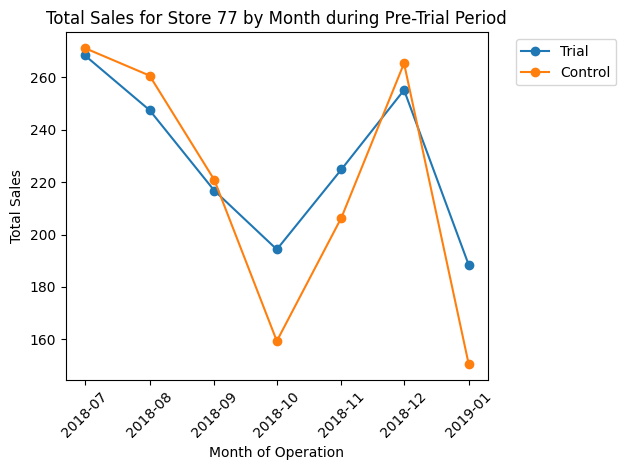

In [35]:
# similarity plot for Total sales for store_77
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

# plot each store type with markers
for t in order:
    subset = matched_77[matched_77['store_type'] == t]
    if not subset.empty:
        plt.plot(subset['TransactionMonth'], subset['total_sales'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Total Sales")
plt.title("Total Sales for Store 77 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

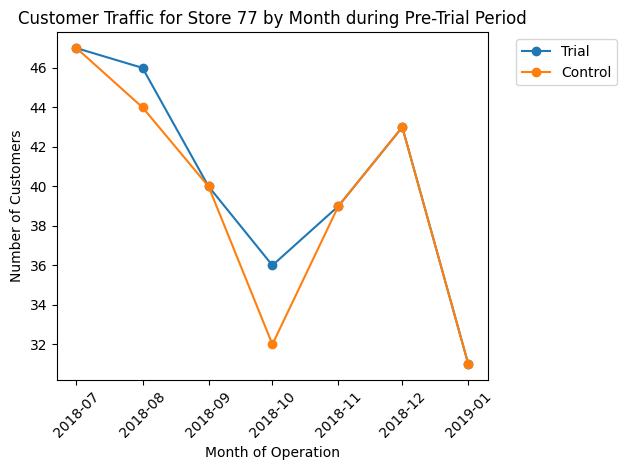

In [36]:
# similarity plot for customer traffic for store_77
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

for t in order:
    subset = matched_77[matched_77['store_type'] == t]
    plt.plot(subset['TransactionMonth'], subset['num_customers'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Number of Customers")
plt.title("Customer Traffic for Store 77 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

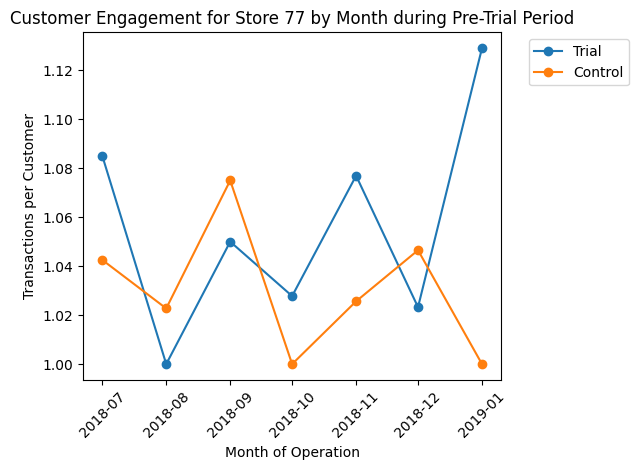

In [37]:
# similarity plot for customer engagement for store_77
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

for t in order:
    subset = matched_77[matched_77['store_type'] == t]
    plt.plot(subset['TransactionMonth'], subset['txn_per_customer'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Transactions per Customer")
plt.title("Customer Engagement for Store 77 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

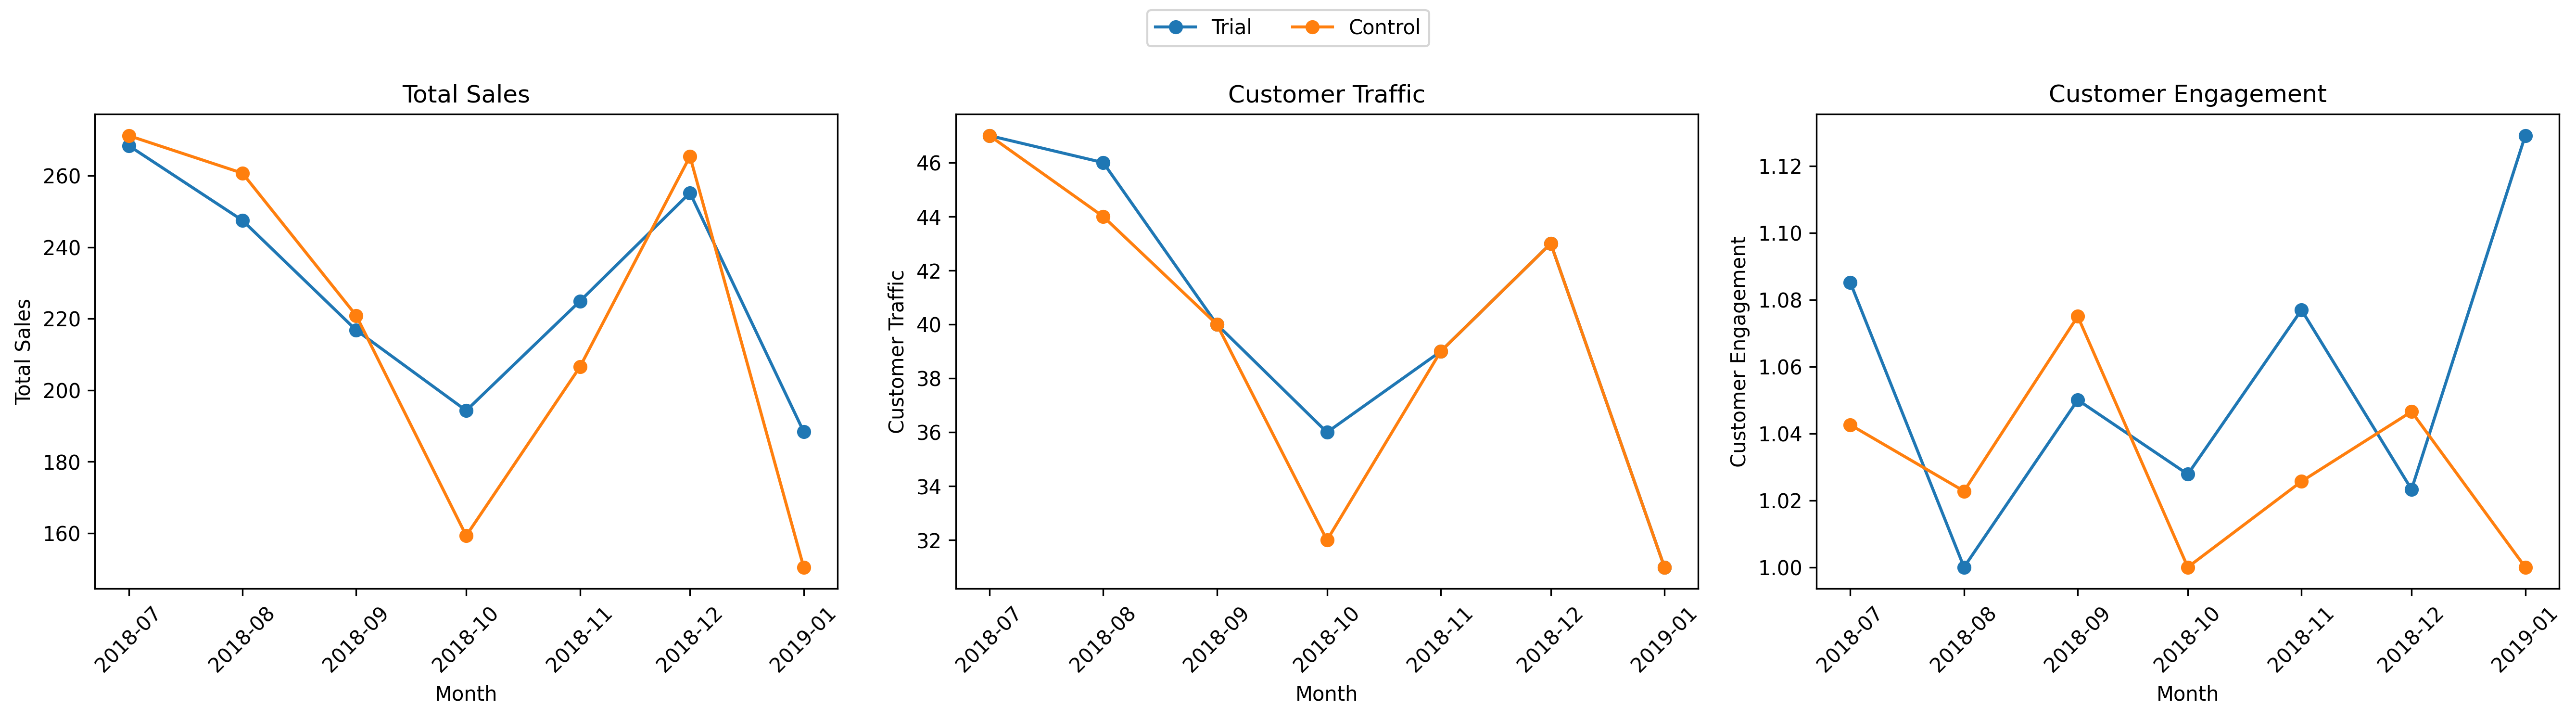

In [109]:
metrics = [
    ("total_sales", "Total Sales"),
    ("num_customers", "Customer Traffic"),
    ("txn_per_customer", "Customer Engagement")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, dpi=300)

order = ['Trial', 'Control']

for ax, (col, title) in zip(axes, metrics):
    for t in order:
        subset = matched_77[matched_77['store_type'] == t]
        ax.plot(subset['TransactionMonth'], subset[col], marker='o', label=t)

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

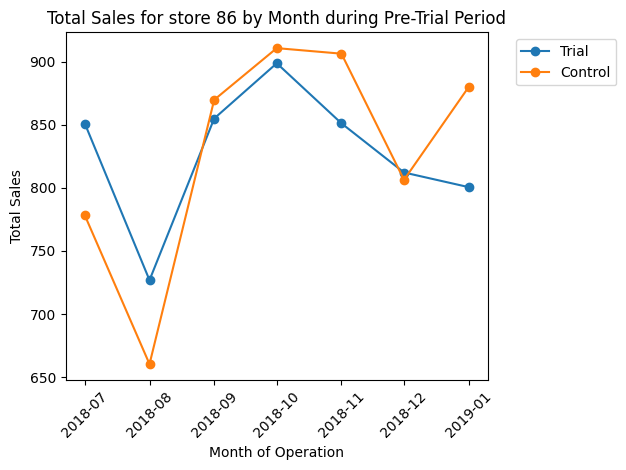

In [39]:
# similarity plot for total sales for store_86
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

# plot each store type with markers
for t in order:
    subset = matched_86[matched_86['store_type'] == t]
    if not subset.empty:
        plt.plot(subset['TransactionMonth'], subset['total_sales'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Total Sales")
plt.title("Total Sales for store 86 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

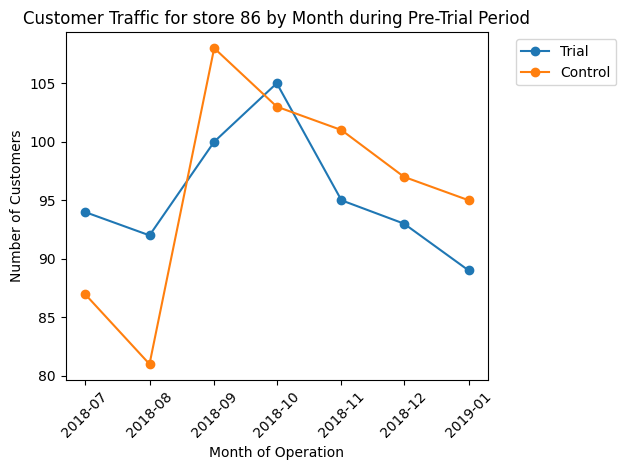

In [40]:
# similarity plot for customer traffic for store_86
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

# plot each store type with markers
for t in order:
    subset = matched_86[matched_86['store_type'] == t]
    if not subset.empty:
        plt.plot(subset['TransactionMonth'], subset['num_customers'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Number of Customers")
plt.title("Customer Traffic for store 86 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

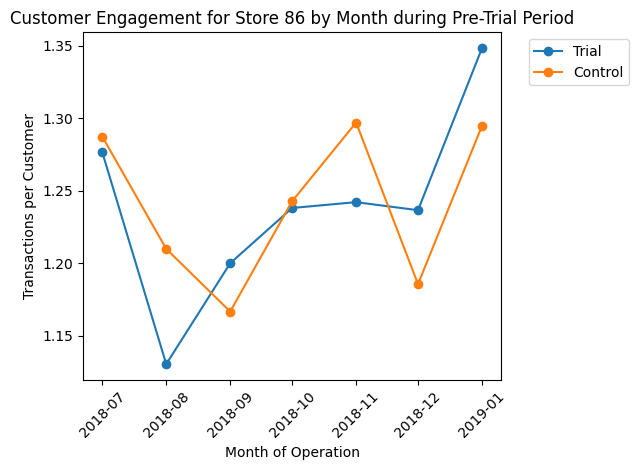

In [41]:
#similarity plot for customer engagement for store_86
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

# plot each store type with markers
for t in order:
    subset = matched_86[matched_86['store_type'] == t]
    if not subset.empty:
        plt.plot(subset['TransactionMonth'], subset['txn_per_customer'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Transactions per Customer")
plt.title("Customer Engagement for Store 86 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

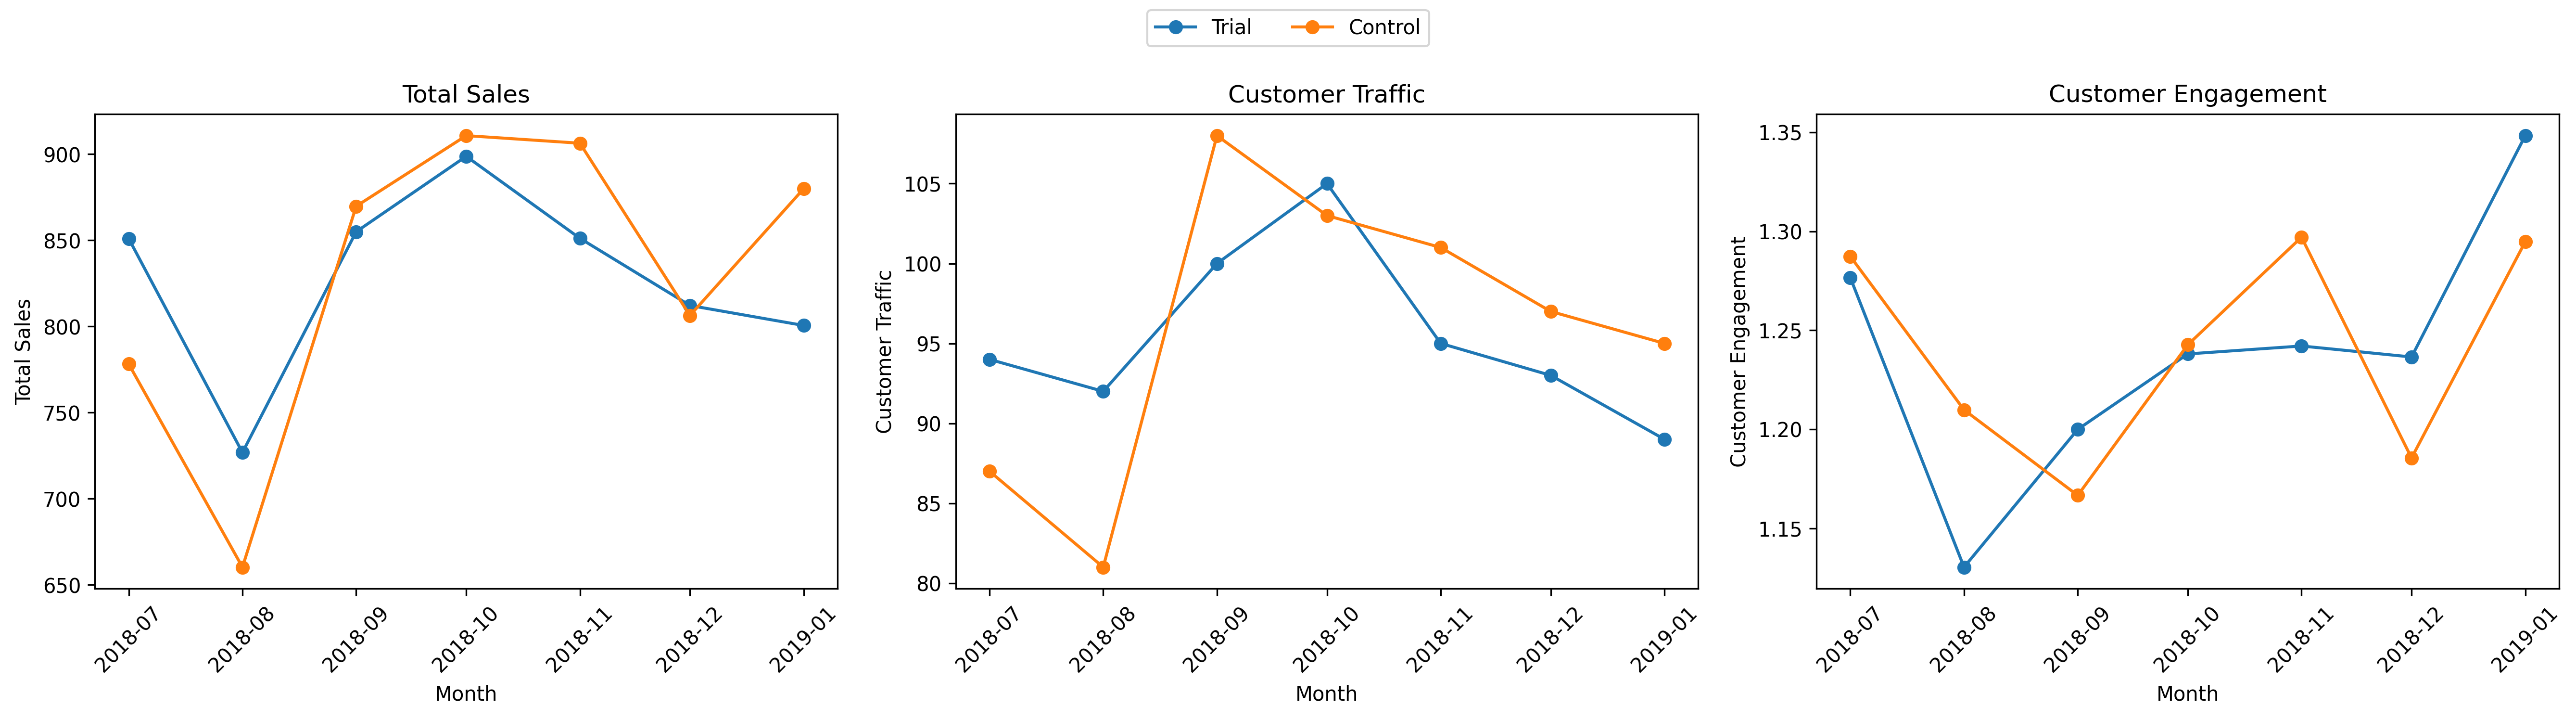

In [111]:
metrics = [
    ("total_sales", "Total Sales"),
    ("num_customers", "Customer Traffic"),
    ("txn_per_customer", "Customer Engagement")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, dpi=300)

order = ['Trial', 'Control']

for ax, (col, title) in zip(axes, metrics):
    for t in order:
        subset = matched_86[matched_86['store_type'] == t]
        ax.plot(subset['TransactionMonth'], subset[col], marker='o', label=t)

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

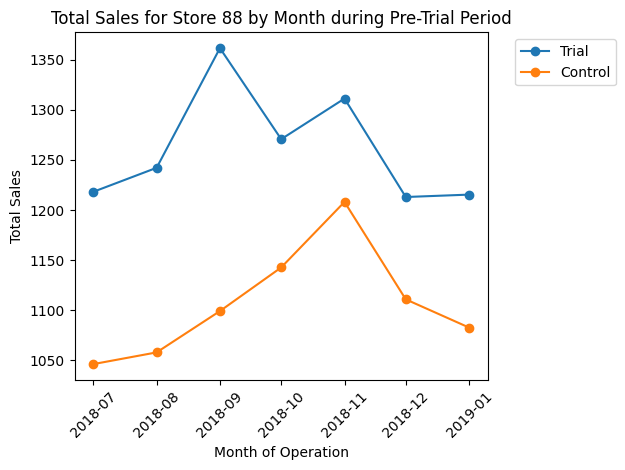

In [43]:
# similarity plot for total sales for store_88
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

# plot each store type with markers
for t in order:
    subset = matched_88[matched_88['store_type'] == t]
    if not subset.empty:
        plt.plot(subset['TransactionMonth'], subset['total_sales'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Total Sales")
plt.title("Total Sales for Store 88 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

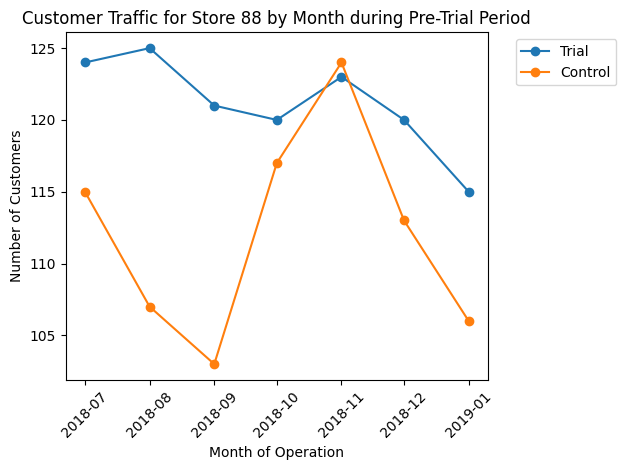

In [44]:
# similarity plot for customer traffic for store_88
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

# plot each store type with markers
for t in order:
    subset = matched_88[matched_88['store_type'] == t]
    if not subset.empty:
        plt.plot(subset['TransactionMonth'], subset['num_customers'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Number of Customers")
plt.title("Customer Traffic for Store 88 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

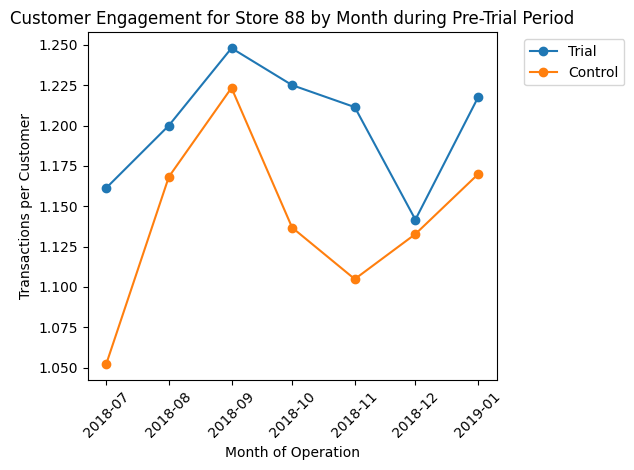

In [45]:
#similarity plot for customer engagement for store_88
plt.figure()

# enforce consistent order 
order = ['Trial', 'Control']

# plot each store type with markers
for t in order:
    subset = matched_88[matched_88['store_type'] == t]
    if not subset.empty:
        plt.plot(subset['TransactionMonth'], subset['txn_per_customer'], label=t, marker='o')

plt.xlabel("Month of Operation")
plt.ylabel("Transactions per Customer")
plt.title("Customer Engagement for Store 88 by Month during Pre-Trial Period")

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

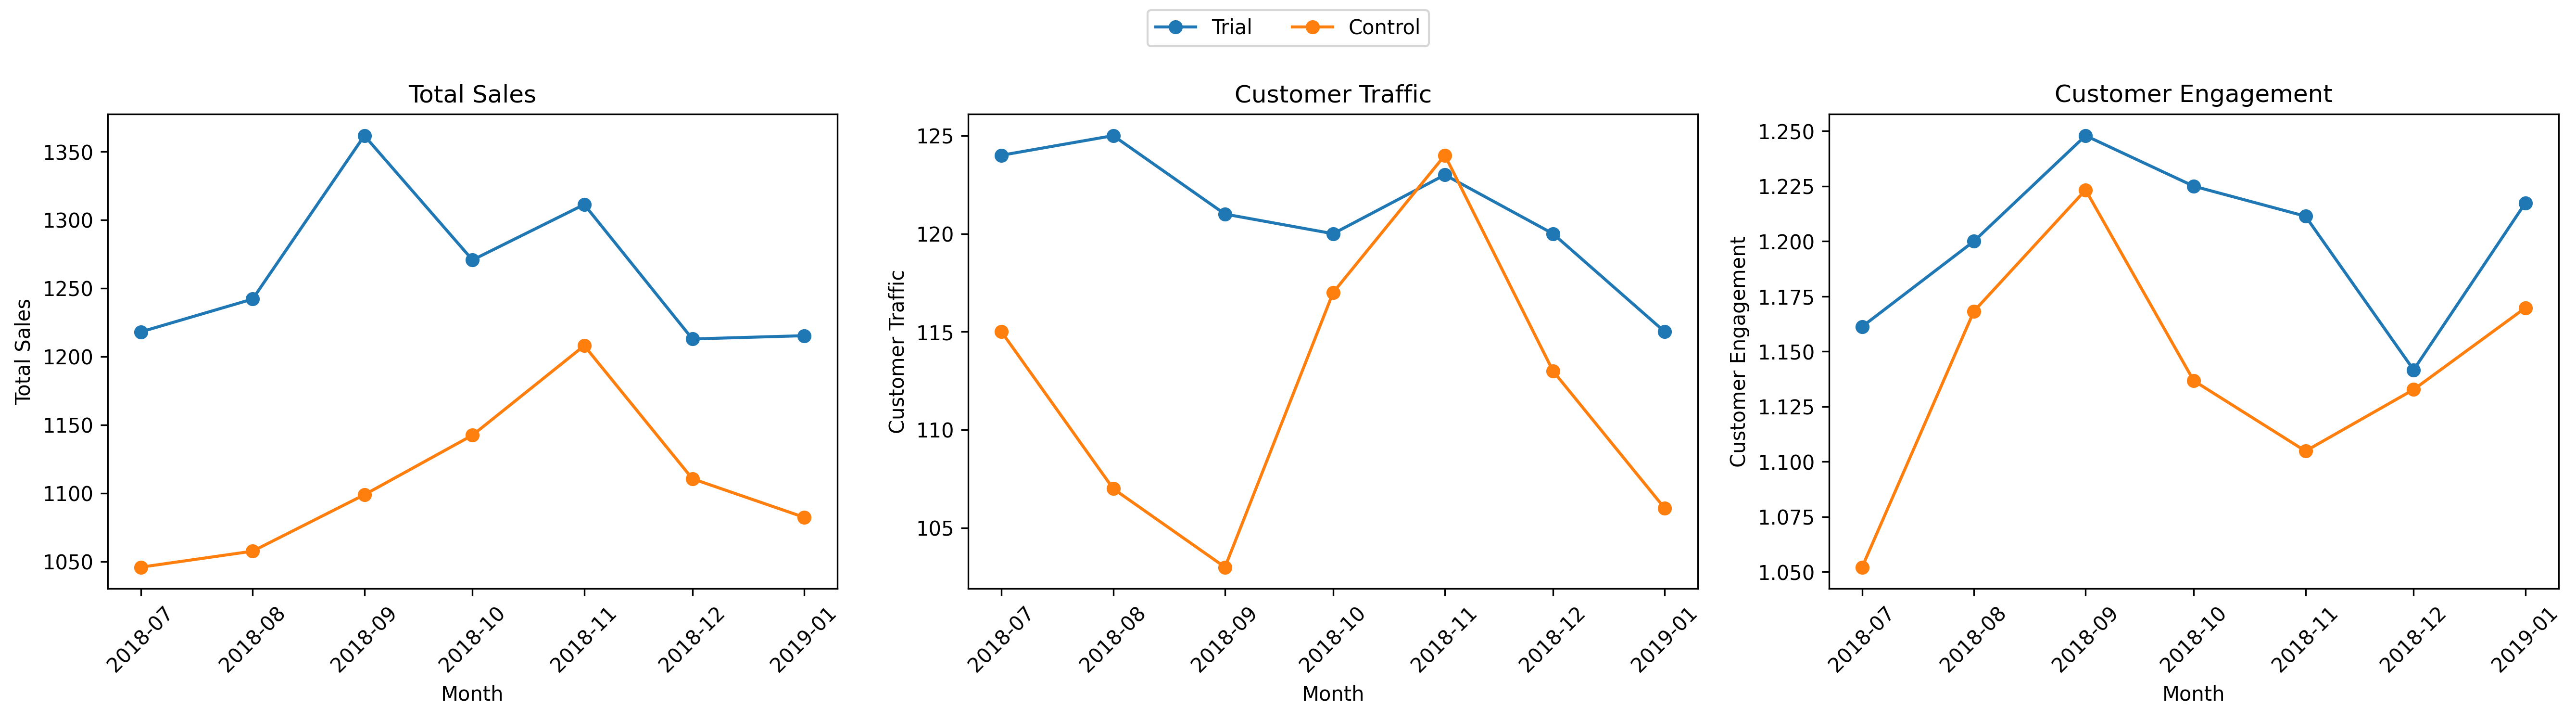

In [112]:
metrics = [
    ("total_sales", "Total Sales"),
    ("num_customers", "Customer Traffic"),
    ("txn_per_customer", "Customer Engagement")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, dpi=300)

order = ['Trial', 'Control']

for ax, (col, title) in zip(axes, metrics):
    for t in order:
        subset = matched_88[matched_88['store_type'] == t]
        ax.plot(subset['TransactionMonth'], subset[col], marker='o', label=t)

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## **Match Store Visual Validation**

After visualizing the trial stores against their matched control stores over the pre-trial period, we observe strong alignment in trend and movement patterns. The stores generally rise and fall together over time, with similar temporal behavior across most of the seven-month baseline window. This supports the suitability of the selected control stores for trial evaluation.

In [47]:
# function to calculate scaling factor for a given metric based on pre-trial period totals
def scaling_fac(input_data, trial_store, control_store, metric):

    trial_sum = input_data[
        input_data['STORE_NBR'] == trial_store
    ][metric].sum()

    control_sum = input_data[
        input_data['STORE_NBR'] == control_store
    ][metric].sum()

    scaling_factor = trial_sum / control_sum

    return scaling_factor

In [48]:
# function to apply scaling factor to control store metric across all months, and create counterfactual
def scaled_control_metric(input_data, trial_store, control_store, metric):

    df = input_data.copy()

    # ensure correct type
    df['YEARMONTH'] = df['YEARMONTH'].astype(int)

    # filter pre-trial for scaling
    pre_trial = df[df['YEARMONTH'] < 201902]

    # compute scaling factor correctly
    scaling_factor = scaling_fac(
        pre_trial,
        trial_store,
        control_store,
        metric
    )

    # column names
    adjusted_metric = f'adjusted_{metric}'
    scaled_metric = f'scaled_control_{metric}'

    # initialize adjusted metric (no NaNs)
    df[adjusted_metric] = df[metric]

    # initialize scaled metric (NaN outside control)
    df[scaled_metric] = np.nan

    # initialize adjusted metric as float
    df[adjusted_metric] = df[metric].astype(float)
    df[scaled_metric] = df[scaled_metric].astype(float)

    # scale only control store
    mask = df['STORE_NBR'] == control_store

    df.loc[mask, adjusted_metric] *= scaling_factor
    df.loc[mask, scaled_metric] = (
        df.loc[mask, metric] * scaling_factor
    )

    return df

In [49]:
matched_77_full = matched_table(summary, 77, store_77['control_store'].iloc[0])
matched_86_full = matched_table(summary, 86, store_86['control_store'].iloc[0])
matched_88_full = matched_table(summary, 88, store_88['control_store'].iloc[0])

In [50]:
matched_88_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 1001 to 2345
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   YEARMONTH         24 non-null     int64         
 1   TransactionMonth  24 non-null     datetime64[ns]
 2   STORE_NBR         24 non-null     int64         
 3   store_type        24 non-null     object        
 4   total_sales       24 non-null     float64       
 5   num_customers     24 non-null     int64         
 6   txn_per_customer  24 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 1.5+ KB


## **UPLIFT ANALYSIS FOR STORE 77**

In [51]:
store77_scaled_sales_control= scaled_control_metric(matched_77_full, 77, store_77['control_store'].iloc[0], 'total_sales')
store77_scaled_sales_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 880 to 2706
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   YEARMONTH                   24 non-null     int64         
 1   TransactionMonth            24 non-null     datetime64[ns]
 2   STORE_NBR                   24 non-null     int64         
 3   store_type                  24 non-null     object        
 4   total_sales                 24 non-null     float64       
 5   num_customers               24 non-null     int64         
 6   txn_per_customer            24 non-null     float64       
 7   adjusted_total_sales        24 non-null     float64       
 8   scaled_control_total_sales  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [52]:
store77_scaled_sales_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_total_sales,scaled_control_total_sales
880,201807,2018-07-01,77,Trial,268.4,47,1.085106,268.4,NaN
881,201808,2018-08-01,77,Trial,247.5,46,1.000000,247.5,NaN
882,201809,2018-09-01,77,Trial,216.8,40,1.050000,216.8,NaN


## **Sales Counterfactual Construction for Store 77**
We construct a counterfactual sales series for Store 77 to estimate how the store would have performed in the absence of the new store layout. The matched control store is used as a proxy for expected performance under the baseline condition.

To ensure comparability, the control series is aligned to the pre-trial period of Store 77, preserving consistency in both level and trend behavior. This approach relies on the assumption that similarity in the pre-trial period reflects parallel movement in the absence of the intervention.

The resulting counterfactual series represents expected performance and serves as the baseline for evaluating the impact of the trial.

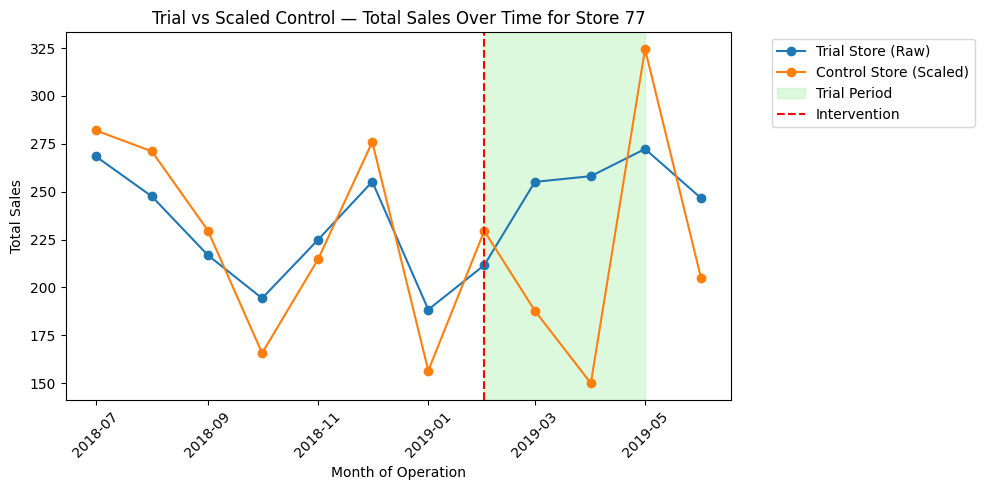

In [53]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store77_scaled_sales_control[
    store77_scaled_sales_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store77_scaled_sales_control[
    store77_scaled_sales_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['total_sales'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_total_sales'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Total Sales")
plt.title("Trial vs Scaled Control — Total Sales Over Time for Store 77")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Actual vs Counterfactual (Preliminary Comparison) for Store 77**

The trial store consistently performs above the control store for most of the trial period, indicating a sustained divergence following the introduction of the new store layout.

At the start of the trial period, both stores exhibit closer alignment and briefly intersect, suggesting comparable baseline conditions prior to divergence. Immediately after the trial period, both the trial and control stores exhibit an upward movement, suggesting a shared time-related or seasonal effect. However, the control store shows a sharper increase followed by a more pronounced decline, suggesting higher short-term volatility compared to the trial store. In contrast, the trial store follows a smoother trajectory over the same period with less extreme fluctuations.

Overall, the sustained separation between the two series during the trial period suggests a potential positive impact of the store layout intervention on sales performance.

In [54]:
def percentage_diff(input_data, trial_store, control_store, metric):

    df = scaled_control_metric(input_data, trial_store, control_store, metric)

    # ensure correct type
    df['YEARMONTH'] = df['YEARMONTH'].astype(int)

    scaled_metric = f'scaled_control_{metric}'

    #view only
    trial_view = df[df['STORE_NBR'] == trial_store].copy()
    control_view = df[df['STORE_NBR'] == control_store].copy()

    # split trial and control
    trial_key = trial_view[['YEARMONTH', metric]]
    control_key = control_view[['YEARMONTH', scaled_metric]]

    # merge on time
    merged = trial_key.merge(
        control_key,
        on='YEARMONTH'
    )

    # avoid division by zero
    denom = merged[scaled_metric].replace(0, np.nan)

    # compute percentage difference
    merged['pct_diff'] = (
        (merged[metric] - denom) / denom
    )

    merged = merged.sort_values('YEARMONTH')

    return merged

In [55]:
print(percentage_diff(matched_77_full, 77, store_77['control_store'].iloc[0], 'total_sales'))

    YEARMONTH  total_sales  scaled_control_total_sales  pct_diff
0      201807        268.4                  281.980841 -0.048162
1      201808        247.5                  271.063441 -0.086930
2      201809        216.8                  229.681297 -0.056083
3      201810        194.3                  165.632551  0.173079
4      201811        224.9                  214.708863  0.047465
5      201812        255.2                  275.950277 -0.075196
6      201901        188.4                  156.482731  0.203967
7      201902        211.6                  229.473346 -0.077889
8      201903        255.1                  187.779277  0.358510
9      201904        258.1                  149.932291  0.721444
10     201905        272.3                  324.506712 -0.160880
11     201906        246.6                  204.831215  0.203918


## **Percentage Uplift vs Counterfactual for Store 77**

To quantify the impact of the store layout intervention on total sales, we compute the percentage difference between the observed trial store performance and the constructed counterfactual baseline:

$$
\text{Pct Difference} = \frac{\text{Trial} - \text{Counterfactual}}{\text{Counterfactual}}
$$

This metric expresses the relative deviation from expected performance under the baseline condition.

Positive values indicate that the trial store outperformed the expected counterfactual, while negative values indicate underperformance.

The results show an initial slight underperformance in the early period, followed by a strong and increasing positive uplift in subsequent months. This suggests that the impact of the trial becomes more pronounced over time rather than being immediate.

In [56]:
def t_statistic_comp(input_data, trial_store, control_store, metric):

    # compute percentage difference series
    df = percentage_diff(input_data, trial_store, control_store, metric).copy()

    # ensure correct type
    df['YEARMONTH'] = df['YEARMONTH'].astype(int)

    # pre-trial period
    pre = df[df['YEARMONTH'] < 201902]

    # standard deviation from pre-trial differences
    stdDev = pre['pct_diff'].std(ddof=1)

    # degrees of freedom
    degreesOfFreedom = len(pre) - 1

    # -------------------------------------------------
    # Null hypothesis: μ = 0 (no difference trial vs control)
    # -------------------------------------------------
    mu = 0

    # compute t-values
    df['tValue'] = (df['pct_diff'] - mu) / stdDev

    # transaction month
    df['TransactionMonth'] = pd.to_datetime(
        df['YEARMONTH'].astype(str) + '01', format='%Y%m%d')

    # compute 95% critical value
    critical = t_dist.ppf(0.95, degreesOfFreedom)

    # compare with critical value
    df['significant'] = df['tValue'] > critical

    # scaled metric column
    scaled_metric = f'scaled_control_{metric}'

    # print inside function (or return it instead)
    print(f'The critical t-value for 95% confidence is: {critical:.3f}')

    return df[['TransactionMonth', metric, scaled_metric, 'pct_diff', 'tValue', 'significant']]

In [57]:
store77_sales_t_comp = t_statistic_comp(matched_77_full, 77, store_77['control_store'].iloc[0], 'total_sales')
print(store77_sales_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  total_sales  scaled_control_total_sales  pct_diff  \
0        2018-07-01        268.4                  281.980841 -0.048162   
1        2018-08-01        247.5                  271.063441 -0.086930   
2        2018-09-01        216.8                  229.681297 -0.056083   
3        2018-10-01        194.3                  165.632551  0.173079   
4        2018-11-01        224.9                  214.708863  0.047465   
5        2018-12-01        255.2                  275.950277 -0.075196   
6        2019-01-01        188.4                  156.482731  0.203967   
7        2019-02-01        211.6                  229.473346 -0.077889   
8        2019-03-01        255.1                  187.779277  0.358510   
9        2019-04-01        258.1                  149.932291  0.721444   
10       2019-05-01        272.3                  324.506712 -0.160880   
11       2019-06-01        246.6                  204.831215  

## **Statistical Significance of Trial Impact on Store 77 sales**

A statistical test was used to assess whether the deviations between the trial store and its counterfactual baseline were large relative to normal pre‑trial variability. The null hypothesis any deviations during the trial should be consistent with natural fluctuations observed before the intervention.

For March and April, the computed t‑values exceed the 95% critical threshold, indicating that the uplift in these months is statistically significant at the 5% level. In other words, the increases observed during these months are unlikely to be explained by pre‑intervention variation alone.

While statistical significance provides evidence of a meaningful deviation from expected performance, it does not by itself quantify the size or business relevance of the uplift. Practical impact should be evaluated separately.

In [58]:
def trial_assessment(input_data, trial_store, control_store, metric):

    input_df = input_data.copy()
    
    scaled_df = scaled_control_metric(input_df, trial_store, control_store, metric)
    scaled_metric = f'scaled_control_{metric}'
    
    # Build Past_metric with both columns temporarily
    Past_metric = scaled_df[['YEARMONTH','store_type', metric, scaled_metric, 'TransactionMonth']].copy()
    
    # Ensure correct types for calculations
    Past_metric[metric] = Past_metric[metric].astype(float)
    Past_metric[scaled_metric] = Past_metric[scaled_metric].astype(float)
    
    # Replace control metric with scaled version
    Past_metric.loc[
        Past_metric['store_type'] == 'Control', metric
    ] = Past_metric.loc[
        Past_metric['store_type'] == 'Control', scaled_metric
    ]
    
    # Drop the scaled column for concat consistency
    Past_metric = Past_metric[['YEARMONTH','store_type', metric, 'TransactionMonth']]


    # percentage differences
    df = percentage_diff(input_df, trial_store, control_store, metric)

    # pre-trial period
    pre = df[df['YEARMONTH'] < 201902]

    # std dev from pre-trial
    stdDev = pre['pct_diff'].std(ddof=1)

    # control series (now scaled)
    control = Past_metric[Past_metric['store_type'] == 'Control'].copy()

    # upper bound
    control_upper = control.copy()
    control_upper[metric] = control_upper[metric] * (1 + stdDev * 2)
    control_upper['store_type'] = f'Control upper 95%\nconfidence bound\nfor {metric}'

    # lower bound
    control_lower = control.copy()
    control_lower[metric] = control_lower[metric] * (1 - stdDev * 2)
    control_lower['store_type'] = f'Control lower 95%\nconfidence bound\nfor {metric}'

    # final result
    result = pd.concat([Past_metric, control_upper, control_lower], ignore_index=True)

    return result


In [59]:
store_77_sales_assessment = trial_assessment(matched_77_full, 77, store_77['control_store'].iloc[0], 'total_sales')
store_77_sales_assessment.head(5)

,YEARMONTH,store_type,total_sales,TransactionMonth
0,201807,Trial,268.4,2018-07-01
1,201808,Trial,247.5,2018-08-01
2,201809,Trial,216.8,2018-09-01
3,201810,Trial,194.3,2018-10-01
4,201811,Trial,224.9,2018-11-01


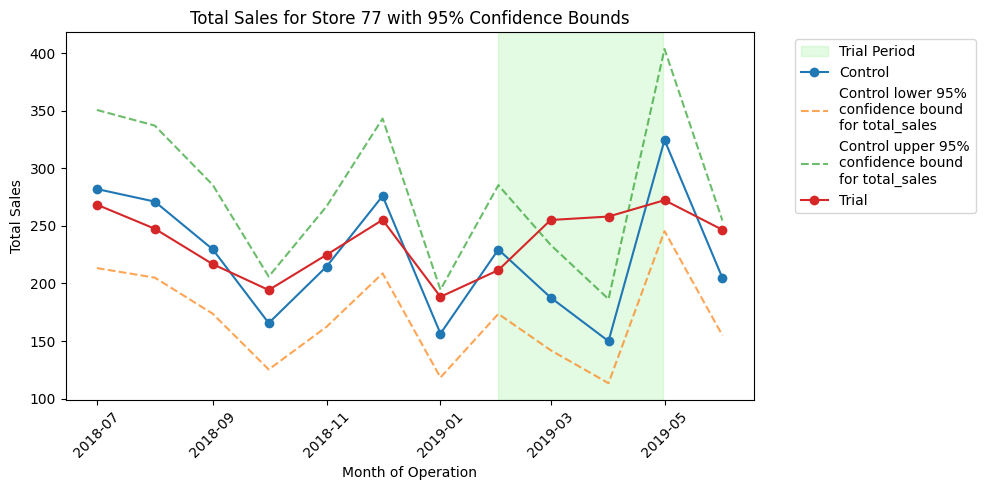

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_77_sales_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['total_sales'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['total_sales'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Total Sales")
ax.set_title("Total Sales for Store 77 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Both the t‑statistic approach and the confidence‑interval method indicate statistically significant deviations of Store 77 total sales from its counterfactual baseline during the trial period. In particular, the trial store falls outside the 95% confidence bounds of the control store in two of the three trial months, which is consistent with the t‑test results showing significant standardized deviations relative to pre‑trial variability.

In [61]:
store77_scaled_ncust_control= scaled_control_metric(matched_77_full, 77, store_77['control_store'].iloc[0], 'num_customers')
store77_scaled_ncust_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 880 to 2706
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   YEARMONTH                     24 non-null     int64         
 1   TransactionMonth              24 non-null     datetime64[ns]
 2   STORE_NBR                     24 non-null     int64         
 3   store_type                    24 non-null     object        
 4   total_sales                   24 non-null     float64       
 5   num_customers                 24 non-null     int64         
 6   txn_per_customer              24 non-null     float64       
 7   adjusted_num_customers        24 non-null     float64       
 8   scaled_control_num_customers  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [62]:
store77_scaled_ncust_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_num_customers,scaled_control_num_customers
880,201807,2018-07-01,77,Trial,268.4,47,1.085106,47.0,NaN
881,201808,2018-08-01,77,Trial,247.5,46,1.000000,46.0,NaN
882,201809,2018-09-01,77,Trial,216.8,40,1.050000,40.0,NaN


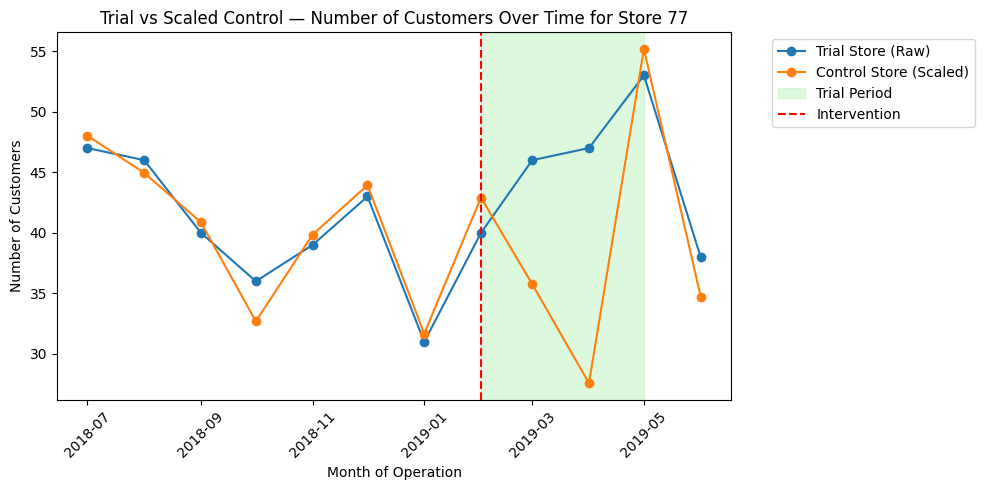

In [63]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store77_scaled_ncust_control[
    store77_scaled_ncust_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store77_scaled_ncust_control[
    store77_scaled_ncust_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['num_customers'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_num_customers'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Number of Customers")
plt.title("Trial vs Scaled Control — Number of Customers Over Time for Store 77")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [64]:
store77_ncust_t_comp = t_statistic_comp(matched_77_full, 77, store_77['control_store'].iloc[0], 'num_customers')
print(store77_ncust_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  num_customers  scaled_control_num_customers  pct_diff  \
0        2018-07-01             47                     48.021739 -0.021277   
1        2018-08-01             46                     44.956522  0.023211   
2        2018-09-01             40                     40.869565 -0.021277   
3        2018-10-01             36                     32.695652  0.101064   
4        2018-11-01             39                     39.847826 -0.021277   
5        2018-12-01             43                     43.934783 -0.021277   
6        2019-01-01             31                     31.673913 -0.021277   
7        2019-02-01             40                     42.913043 -0.067882   
8        2019-03-01             46                     35.760870  0.286322   
9        2019-04-01             47                     27.586957  0.703704   
10       2019-05-01             53                     55.173913 -0.039401   
11       2019-

In [65]:
store_77_ncust_assessment = trial_assessment(matched_77_full, 77, store_77['control_store'].iloc[0], 'num_customers')
store_77_ncust_assessment.head(5)

,YEARMONTH,store_type,num_customers,TransactionMonth
0,201807,Trial,47.0,2018-07-01
1,201808,Trial,46.0,2018-08-01
2,201809,Trial,40.0,2018-09-01
3,201810,Trial,36.0,2018-10-01
4,201811,Trial,39.0,2018-11-01


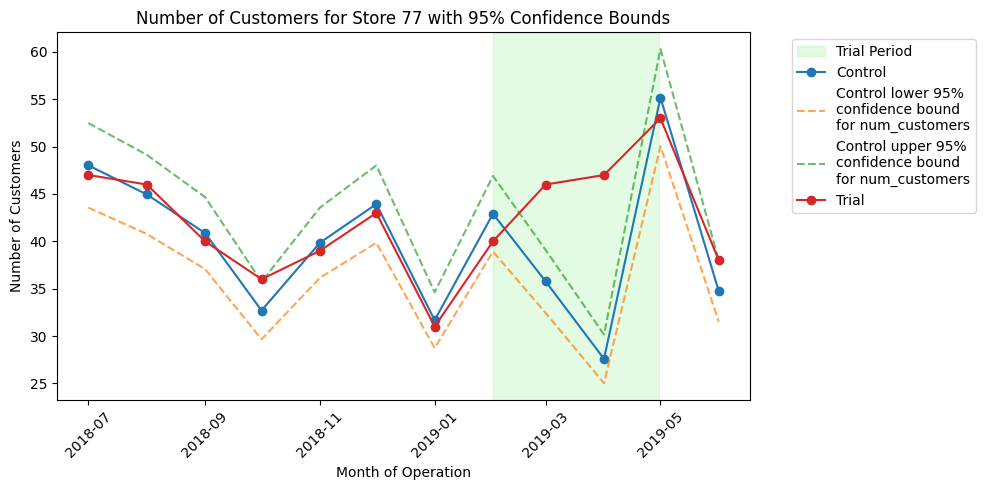

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_77_ncust_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['num_customers'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['num_customers'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Number of Customers")
ax.set_title("Number of Customers for Store 77 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Customer Count Impact -Store 77**

We apply the same counterfactual and significance testing framework to customer count.

The trial stores show a similar directional pattern to total sales revenue, with a general uplift observed relative to their matched control stores during the trial period. In most cases, this uplift is statistically significant and consistent with the sales results.

This suggests that the increase in revenue is partially driven by increased customer traffic.

In [67]:
store77_scaled_txn_control= scaled_control_metric(matched_77_full, 77, store_77['control_store'].iloc[0], 'txn_per_customer')
store77_scaled_txn_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 880 to 2706
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   YEARMONTH                        24 non-null     int64         
 1   TransactionMonth                 24 non-null     datetime64[ns]
 2   STORE_NBR                        24 non-null     int64         
 3   store_type                       24 non-null     object        
 4   total_sales                      24 non-null     float64       
 5   num_customers                    24 non-null     int64         
 6   txn_per_customer                 24 non-null     float64       
 7   adjusted_txn_per_customer        24 non-null     float64       
 8   scaled_control_txn_per_customer  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [68]:
store77_scaled_txn_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_txn_per_customer,scaled_control_txn_per_customer
880,201807,2018-07-01,77,Trial,268.4,47,1.085106,1.085106,NaN
881,201808,2018-08-01,77,Trial,247.5,46,1.000000,1.000000,NaN
882,201809,2018-09-01,77,Trial,216.8,40,1.050000,1.050000,NaN


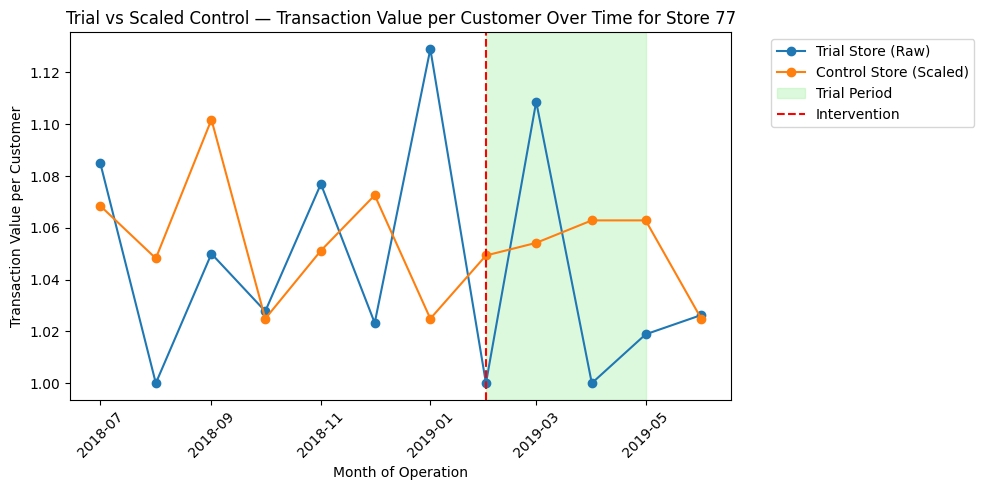

In [69]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store77_scaled_txn_control[
    store77_scaled_txn_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store77_scaled_txn_control[
    store77_scaled_txn_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['txn_per_customer'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_txn_per_customer'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Transaction Value per Customer")
plt.title("Trial vs Scaled Control — Transaction Value per Customer Over Time for Store 77")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [70]:
store77_txn_t_comp = t_statistic_comp(matched_77_full, 77, store_77['control_store'].iloc[0], 'txn_per_customer')
print(store77_txn_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  txn_per_customer  scaled_control_txn_per_customer  \
0        2018-07-01          1.085106                         1.068523   
1        2018-08-01          1.000000                         1.048203   
2        2018-09-01          1.050000                         1.101778   
3        2018-10-01          1.027778                         1.024910   
4        2018-11-01          1.076923                         1.051190   
5        2018-12-01          1.023256                         1.072580   
6        2019-01-01          1.129032                         1.024910   
7        2019-02-01          1.000000                         1.049313   
8        2019-03-01          1.108696                         1.054193   
9        2019-04-01          1.000000                         1.062870   
10       2019-05-01          1.018868                         1.062870   
11       2019-06-01          1.026316                         

In [71]:
store_77_txn_assessment = trial_assessment(matched_77_full, 77, store_77['control_store'].iloc[0], 'txn_per_customer')
store_77_txn_assessment.head(5)

,YEARMONTH,store_type,txn_per_customer,TransactionMonth
0,201807,Trial,1.085106,2018-07-01
1,201808,Trial,1.000000,2018-08-01
2,201809,Trial,1.050000,2018-09-01
3,201810,Trial,1.027778,2018-10-01
4,201811,Trial,1.076923,2018-11-01


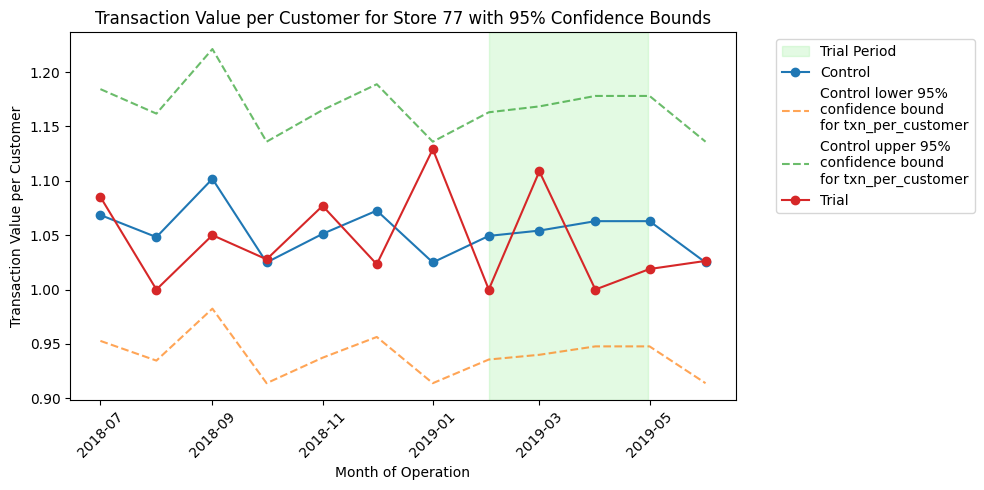

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_77_txn_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['txn_per_customer'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['txn_per_customer'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Transaction Value per Customer")
ax.set_title("Transaction Value per Customer for Store 77 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Transactions per Customer Impact - Store 77**

In contrast to total sales and customer count, transactions per customer in Store 77 show a weaker and less consistent response to the store layout intervention.

Only one of the three trial months exhibits a noticeable increase relative to the control store, while the remaining months are below control store performance.

From a statistical perspective, there is no evidence of statistical significance across the full trial period, as all observations remain within the confidence bounds of the control distribution. In other words, transaction frequency remains within the expected range of baseline variation throughout the trial period.

This suggests that the observed uplift in total sales is primarily driven by increases in customer count rather than changes in purchase frequency per customer.

In [113]:
def plot_metric(ax, df, metric, title, trial_start, trial_end):
    ax.axvspan(trial_start, trial_end, color='lightgreen', alpha=0.25)

    for key, grp in df.groupby('store_type'):
        grp = grp.sort_values('TransactionMonth')

        if "upper" in key.lower():
            style = dict(linestyle='--', alpha=0.7)
            label = "Control Upper 95% CI"
        elif "lower" in key.lower():
            style = dict(linestyle='--', alpha=0.7)
            label = "Control Lower 95% CI"
        else:
            style = dict(marker='o')
            label = key

        ax.plot(grp['TransactionMonth'], grp[metric], label=label, **style)

    ax.set_ylabel(metric.replace("_", " ").title())

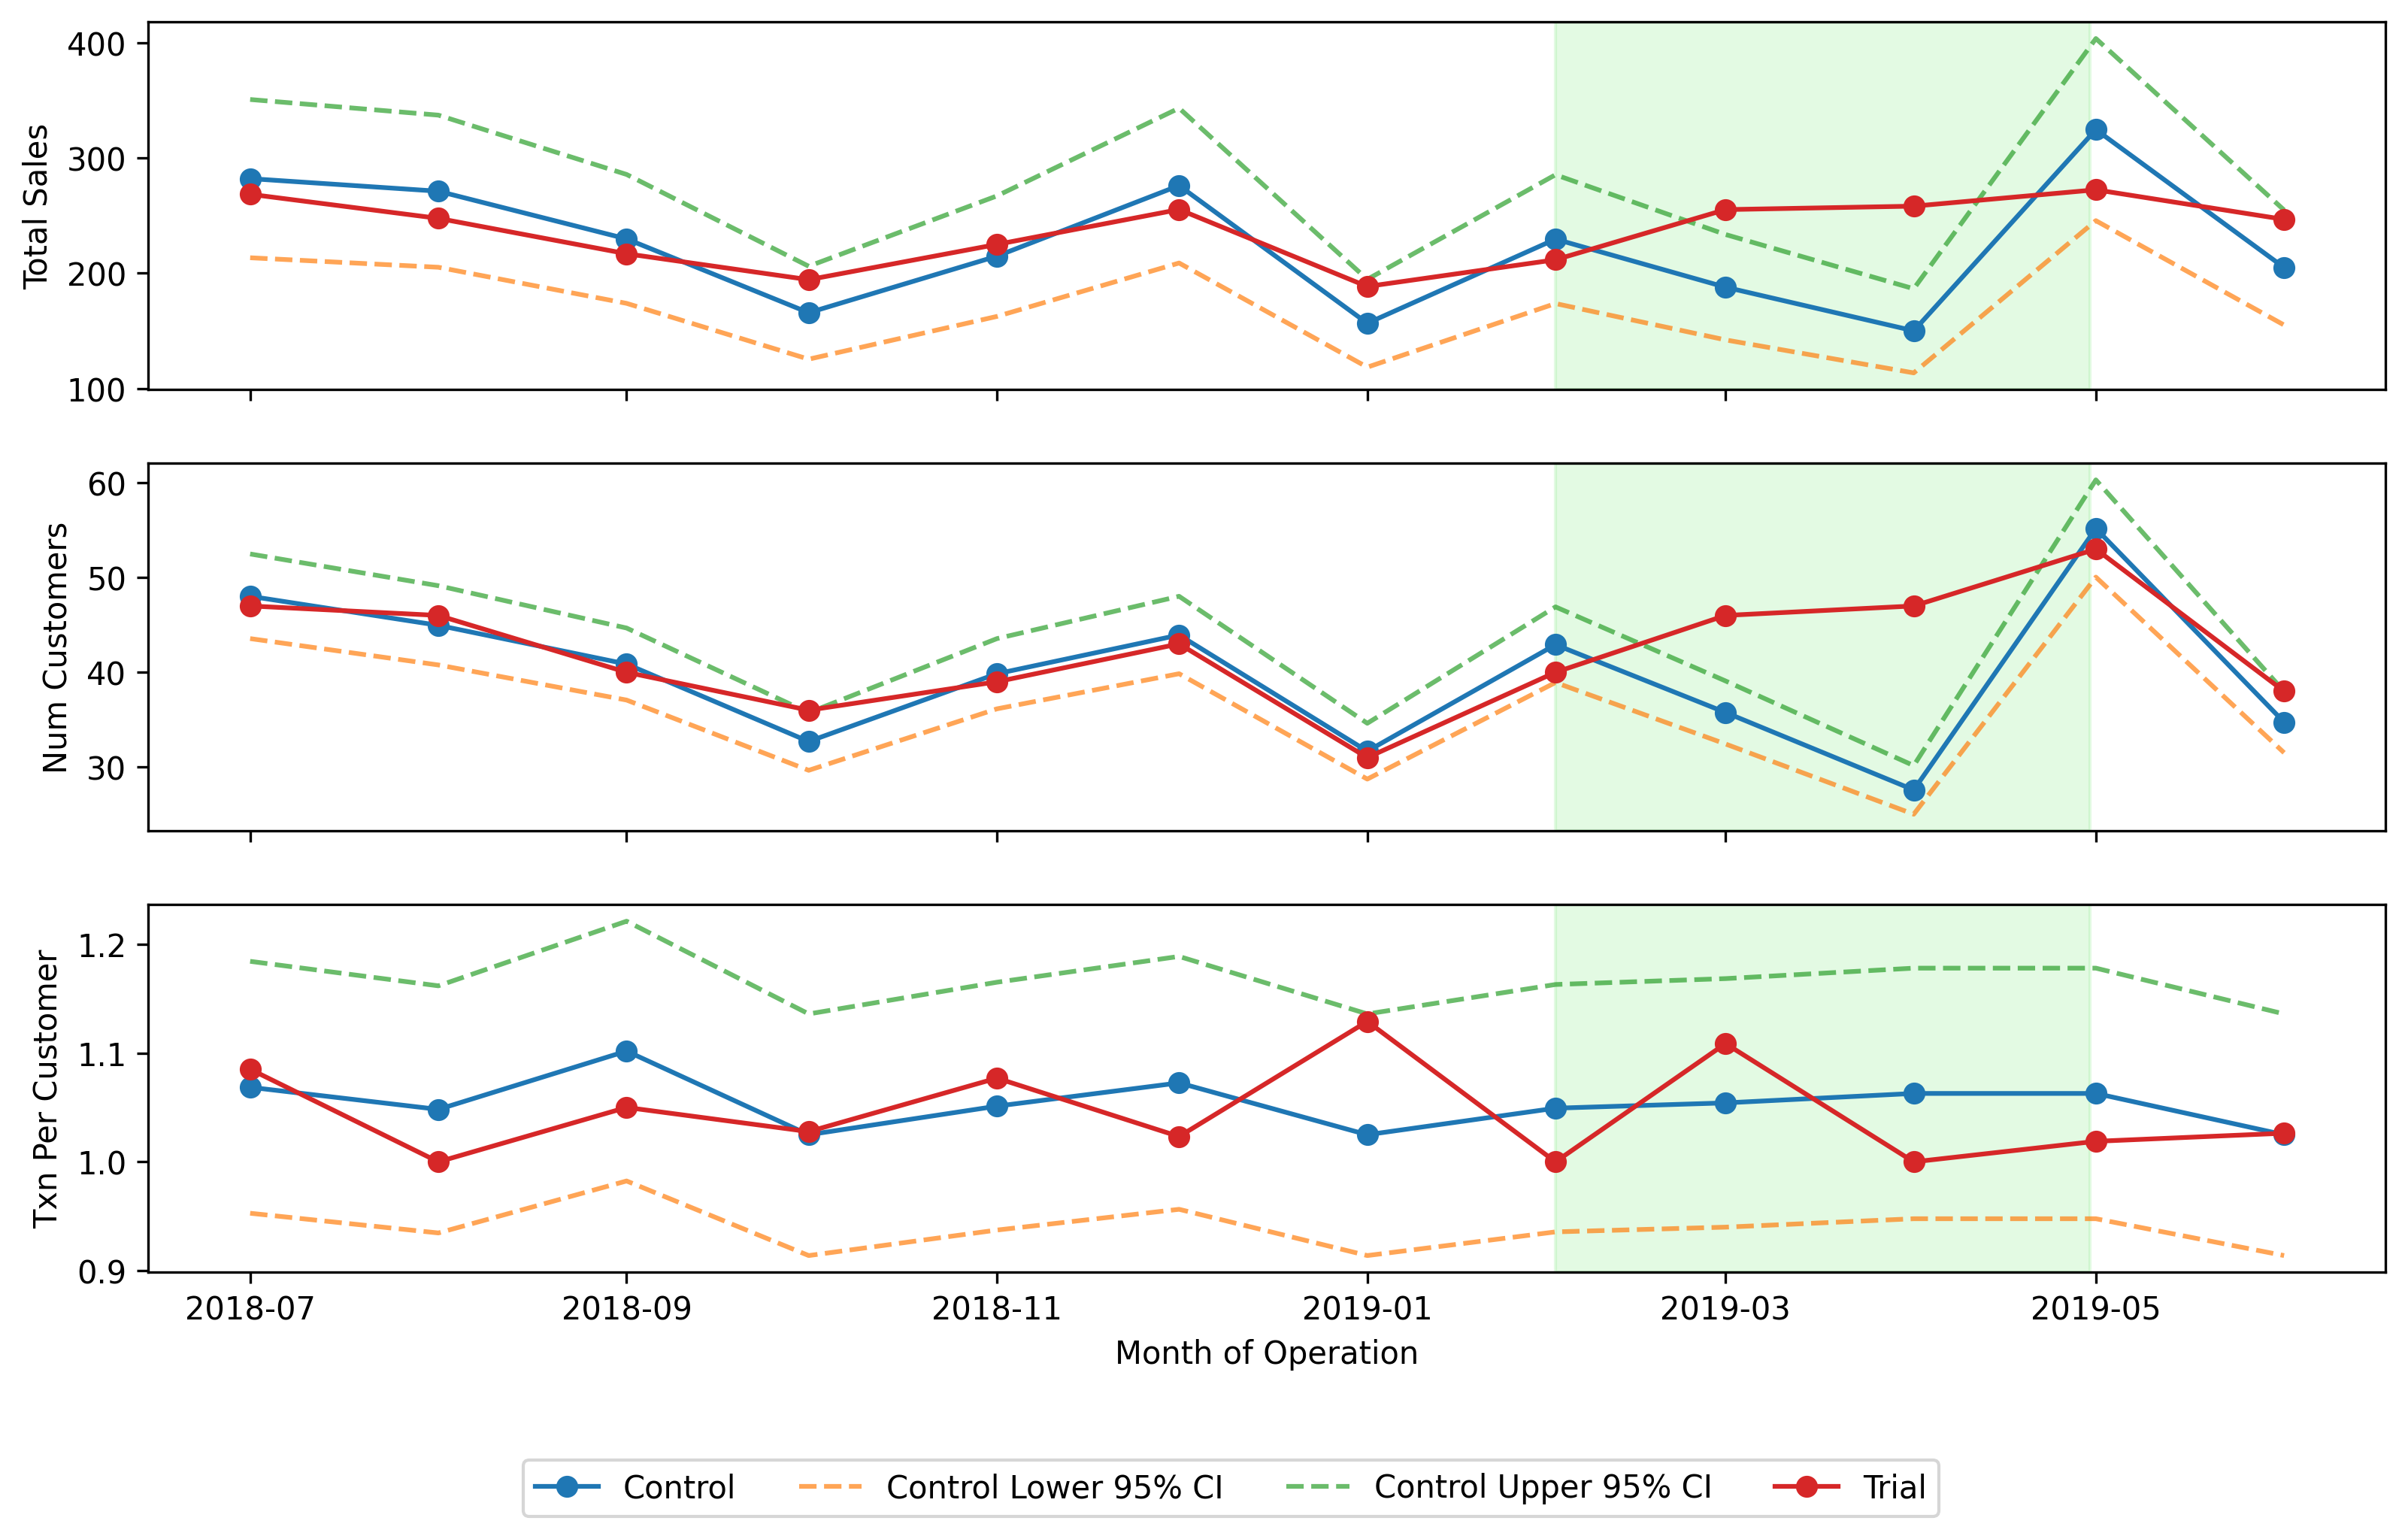

In [115]:
fig, axes = plt.subplots(3, 1, figsize=(12.8, 7.2), sharex=True, dpi=300)

datasets = [
    (store_77_sales_assessment, "total_sales", "Total Sales"),
    (store_77_ncust_assessment, "num_customers", "Number of Customers"),
    (store_77_txn_assessment, "txn_per_customer", "Transactions per Customer")
]

for ax, (df, metric, title) in zip(axes, datasets):
    plot_metric(ax, df, metric, title, trial_start, trial_end)

axes[-1].set_xlabel("Month of Operation")
handles, labels = axes[0].get_legend_handles_labels()

by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4
)

## **STORE 77 CONCLUSION**

Overall, Store 77 shows a clear positive impact of the new store layout, with statistically significant uplifts in total sales and customer count, while transactions per customer remain unchanged. This suggests that the improvement is primarily driven by increased customer traffic rather than changes in purchasing behaviour.

## **UPLIFT ANALYSIS FOR STORE 86**

In [73]:
store86_scaled_sales_control= scaled_control_metric(matched_86_full, 86, store_86['control_store'].iloc[0], 'total_sales')
store86_scaled_sales_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 977 to 1599
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   YEARMONTH                   24 non-null     int64         
 1   TransactionMonth            24 non-null     datetime64[ns]
 2   STORE_NBR                   24 non-null     int64         
 3   store_type                  24 non-null     object        
 4   total_sales                 24 non-null     float64       
 5   num_customers               24 non-null     int64         
 6   txn_per_customer            24 non-null     float64       
 7   adjusted_total_sales        24 non-null     float64       
 8   scaled_control_total_sales  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [74]:
store86_scaled_sales_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_total_sales,scaled_control_total_sales
977,201807,2018-07-01,86,Trial,851.00,94,1.276596,851.00,NaN
978,201808,2018-08-01,86,Trial,726.85,92,1.130435,726.85,NaN
979,201809,2018-09-01,86,Trial,855.00,100,1.200000,855.00,NaN


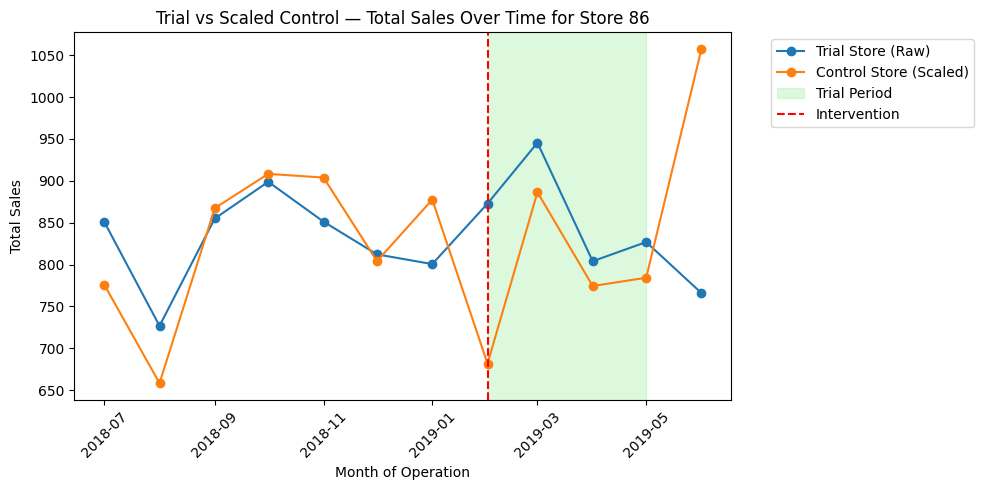

In [75]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store86_scaled_sales_control[
    store86_scaled_sales_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store86_scaled_sales_control[
    store86_scaled_sales_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['total_sales'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_total_sales'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Total Sales")
plt.title("Trial vs Scaled Control — Total Sales Over Time for Store 86")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [76]:
store86_sales_t_comp = t_statistic_comp(matched_86_full, 86, store_86['control_store'].iloc[0], 'total_sales')
print(store86_sales_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  total_sales  scaled_control_total_sales  pct_diff  \
0        2018-07-01       851.00                  776.024162  0.096615   
1        2018-08-01       726.85                  658.453809  0.103874   
2        2018-09-01       855.00                  867.368050 -0.014259   
3        2018-10-01       898.80                  908.253415 -0.010408   
4        2018-11-01       851.20                  903.865717 -0.058267   
5        2018-12-01       812.20                  804.145316  0.010016   
6        2019-01-01       800.60                  877.539531 -0.087676   
7        2019-02-01       872.80                  681.888104  0.279975   
8        2019-03-01       945.40                  886.314926  0.066664   
9        2019-04-01       804.00                  774.428636  0.038185   
10       2019-05-01       826.90                  784.300956  0.054315   
11       2019-06-01       766.00                 1057.235694 -

In [77]:
store_86_sales_assessment = trial_assessment(matched_86_full, 86, store_86['control_store'].iloc[0], 'total_sales')
store_86_sales_assessment.head(5)

,YEARMONTH,store_type,total_sales,TransactionMonth
0,201807,Trial,851.00,2018-07-01
1,201808,Trial,726.85,2018-08-01
2,201809,Trial,855.00,2018-09-01
3,201810,Trial,898.80,2018-10-01
4,201811,Trial,851.20,2018-11-01


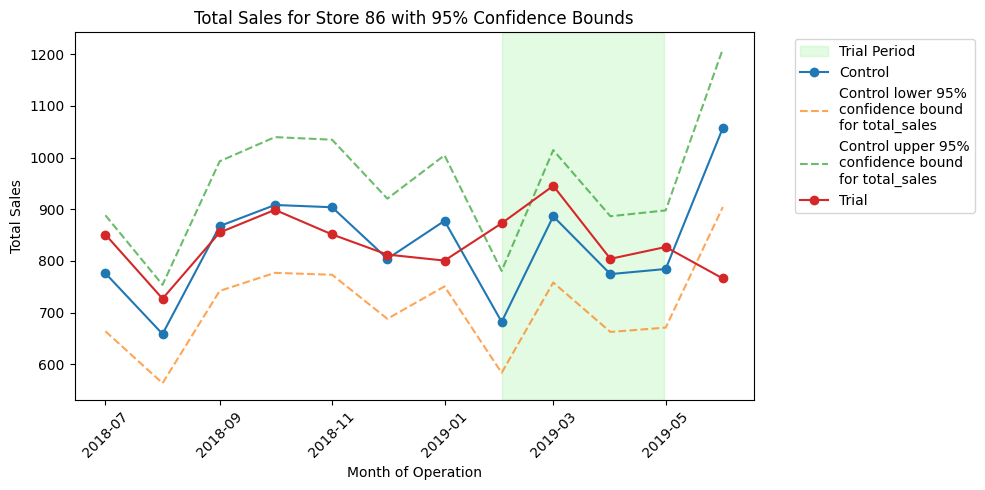

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_86_sales_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['total_sales'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['total_sales'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Total Sales")
ax.set_title("Total Sales for Store 86 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Store 86 Total Sales Insights**

While Store 86 shows a consistent uplift in total sales during the trial period, this increase is not statistically significant. Most monthly observations remain within the 95% confidence bounds of the control store, indicating that the observed uplift may be driven by normal variation rather than a strong intervention effect.

In contrast to Store 77, where the uplift is both stronger and statistically significant, Store 86 exhibits a more muted response to the store layout change.

In [79]:
store86_scaled_ncust_control= scaled_control_metric(matched_86_full, 86, store_86['control_store'].iloc[0], 'num_customers')
store86_scaled_ncust_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 977 to 1599
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   YEARMONTH                     24 non-null     int64         
 1   TransactionMonth              24 non-null     datetime64[ns]
 2   STORE_NBR                     24 non-null     int64         
 3   store_type                    24 non-null     object        
 4   total_sales                   24 non-null     float64       
 5   num_customers                 24 non-null     int64         
 6   txn_per_customer              24 non-null     float64       
 7   adjusted_num_customers        24 non-null     float64       
 8   scaled_control_num_customers  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [80]:
store86_scaled_ncust_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_num_customers,scaled_control_num_customers
977,201807,2018-07-01,86,Trial,851.00,94,1.276596,94.0,NaN
978,201808,2018-08-01,86,Trial,726.85,92,1.130435,92.0,NaN
979,201809,2018-09-01,86,Trial,855.00,100,1.200000,100.0,NaN


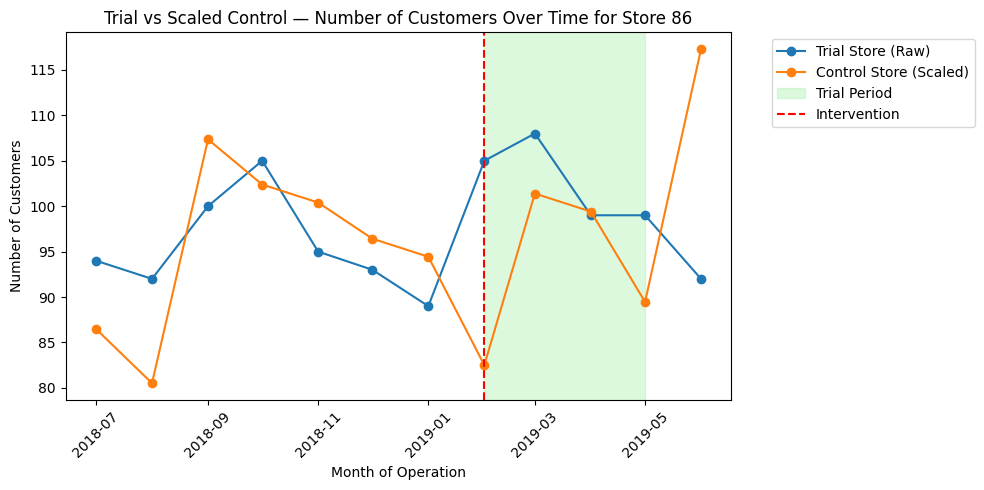

In [81]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store86_scaled_ncust_control[
    store86_scaled_ncust_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store86_scaled_ncust_control[
    store86_scaled_ncust_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['num_customers'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_num_customers'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Number of Customers")
plt.title("Trial vs Scaled Control — Number of Customers Over Time for Store 86")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [82]:
store86_ncust_t_comp = t_statistic_comp(matched_86_full, 86, store_86['control_store'].iloc[0], 'num_customers')
print(store86_ncust_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  num_customers  scaled_control_num_customers  pct_diff  \
0        2018-07-01             94                     86.482143  0.086930   
1        2018-08-01             92                     80.517857  0.142604   
2        2018-09-01            100                    107.357143 -0.068530   
3        2018-10-01            105                    102.386905  0.025522   
4        2018-11-01             95                    100.398810 -0.053774   
5        2018-12-01             93                     96.422619 -0.035496   
6        2019-01-01             89                     94.434524 -0.057548   
7        2019-02-01            105                     82.505952  0.272635   
8        2019-03-01            108                    101.392857  0.065164   
9        2019-04-01             99                     99.404762 -0.004072   
10       2019-05-01             99                     89.464286  0.106587   
11       2019-

In [83]:
store_86_ncust_assessment = trial_assessment(matched_86_full, 86, store_86['control_store'].iloc[0], 'num_customers')
store_86_ncust_assessment.head(5)

,YEARMONTH,store_type,num_customers,TransactionMonth
0,201807,Trial,94.0,2018-07-01
1,201808,Trial,92.0,2018-08-01
2,201809,Trial,100.0,2018-09-01
3,201810,Trial,105.0,2018-10-01
4,201811,Trial,95.0,2018-11-01


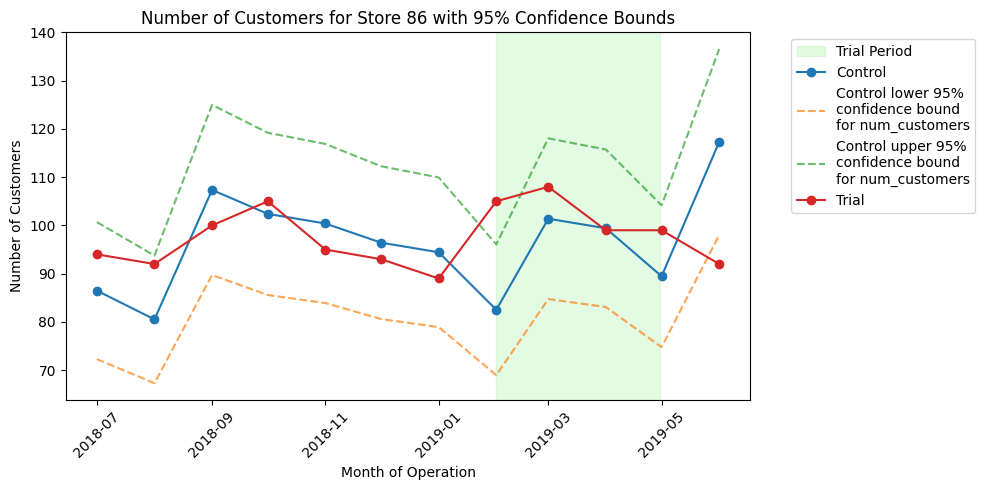

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_86_ncust_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['num_customers'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['num_customers'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Number of Customers")
ax.set_title("Number of Customers for Store 86 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Customer Count Impact — Store 86**

There is an uplift in customer count for most of the trial period, with one month performing close to the control store level.

However, only one month shows statistical significance, while the remaining months are not significant and lie within the confidence bounds of the control distribution. This suggests that the uplift in customer count is not consistently sustained throughout the trial period.

In [85]:
store86_scaled_txn_control= scaled_control_metric(matched_86_full, 86, store_86['control_store'].iloc[0], 'txn_per_customer')
store86_scaled_txn_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 977 to 1599
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   YEARMONTH                        24 non-null     int64         
 1   TransactionMonth                 24 non-null     datetime64[ns]
 2   STORE_NBR                        24 non-null     int64         
 3   store_type                       24 non-null     object        
 4   total_sales                      24 non-null     float64       
 5   num_customers                    24 non-null     int64         
 6   txn_per_customer                 24 non-null     float64       
 7   adjusted_txn_per_customer        24 non-null     float64       
 8   scaled_control_txn_per_customer  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [86]:
store86_scaled_txn_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_txn_per_customer,scaled_control_txn_per_customer
977,201807,2018-07-01,86,Trial,851.00,94,1.276596,1.276596,NaN
978,201808,2018-08-01,86,Trial,726.85,92,1.130435,1.130435,NaN
979,201809,2018-09-01,86,Trial,855.00,100,1.200000,1.200000,NaN


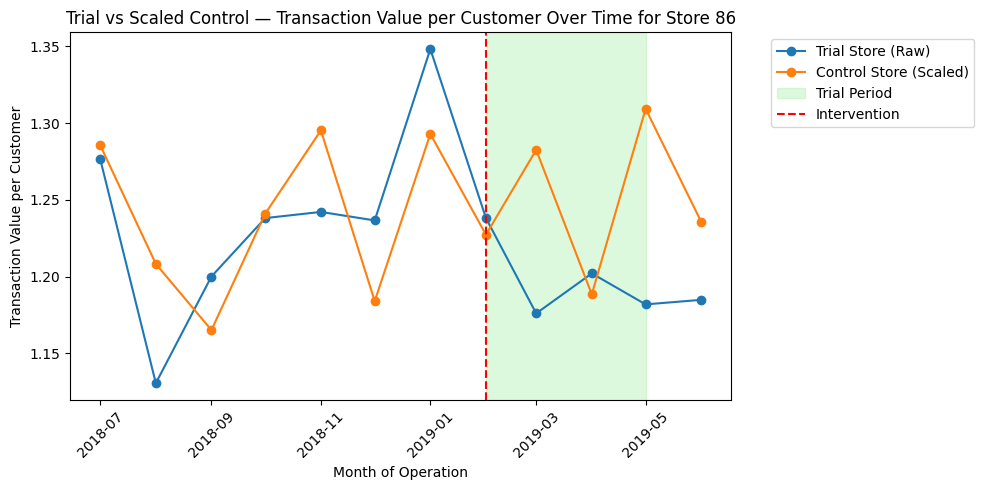

In [87]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store86_scaled_txn_control[
    store86_scaled_txn_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store86_scaled_txn_control[
    store86_scaled_txn_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['txn_per_customer'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_txn_per_customer'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Transaction Value per Customer")
plt.title("Trial vs Scaled Control — Transaction Value per Customer Over Time for Store 86")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [88]:
store86_txn_t_comp = t_statistic_comp(matched_86_full, 86, store_86['control_store'].iloc[0], 'txn_per_customer')
print(store86_txn_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  txn_per_customer  scaled_control_txn_per_customer  \
0        2018-07-01          1.276596                         1.285600   
1        2018-08-01          1.130435                         1.208226   
2        2018-09-01          1.200000                         1.165075   
3        2018-10-01          1.238095                         1.241023   
4        2018-11-01          1.242105                         1.295260   
5        2018-12-01          1.236559                         1.183950   
6        2019-01-01          1.348315                         1.292971   
7        2019-02-01          1.238095                         1.227239   
8        2019-03-01          1.175926                         1.282562   
9        2019-04-01          1.202020                         1.188377   
10       2019-05-01          1.181818                         1.309322   
11       2019-06-01          1.184783                         

In [89]:
store_86_txn_assessment = trial_assessment(matched_86_full, 86, store_86['control_store'].iloc[0], 'txn_per_customer')
store_86_txn_assessment.head(5)

,YEARMONTH,store_type,txn_per_customer,TransactionMonth
0,201807,Trial,1.276596,2018-07-01
1,201808,Trial,1.130435,2018-08-01
2,201809,Trial,1.200000,2018-09-01
3,201810,Trial,1.238095,2018-10-01
4,201811,Trial,1.242105,2018-11-01


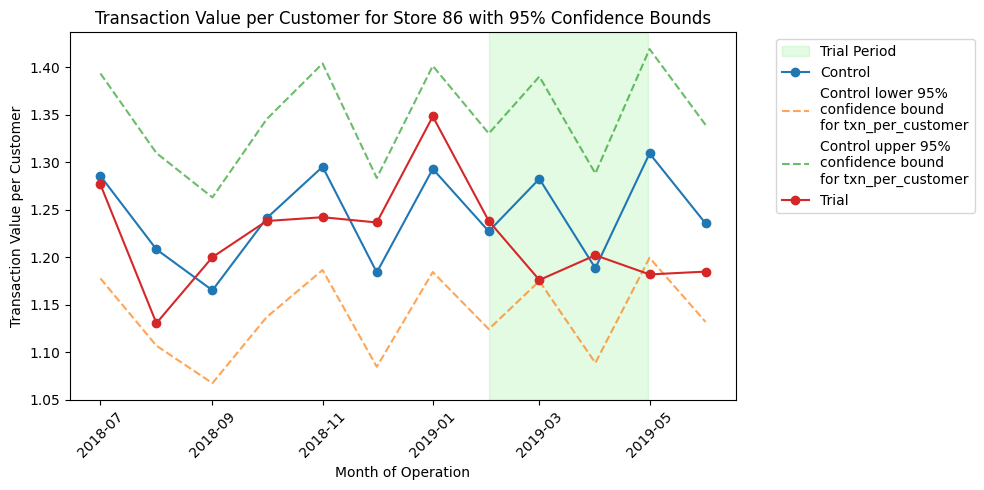

In [90]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_86_txn_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['txn_per_customer'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['txn_per_customer'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Transaction Value per Customer")
ax.set_title("Transaction Value per Customer for Store 86 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Transactions per Customer Impact — Store 86**

Transactions per customer in Store 86 slightly exceed the control store in two months, with a dip in the middle month before rising again to nearly match the control level.

However, there is no statistical significance across any of the trial months, as all observations remain comfortably within the confidence bounds of the control distribution. This indicates that transaction frequency per customer remains broadly consistent with expected baseline variation throughout the trial period

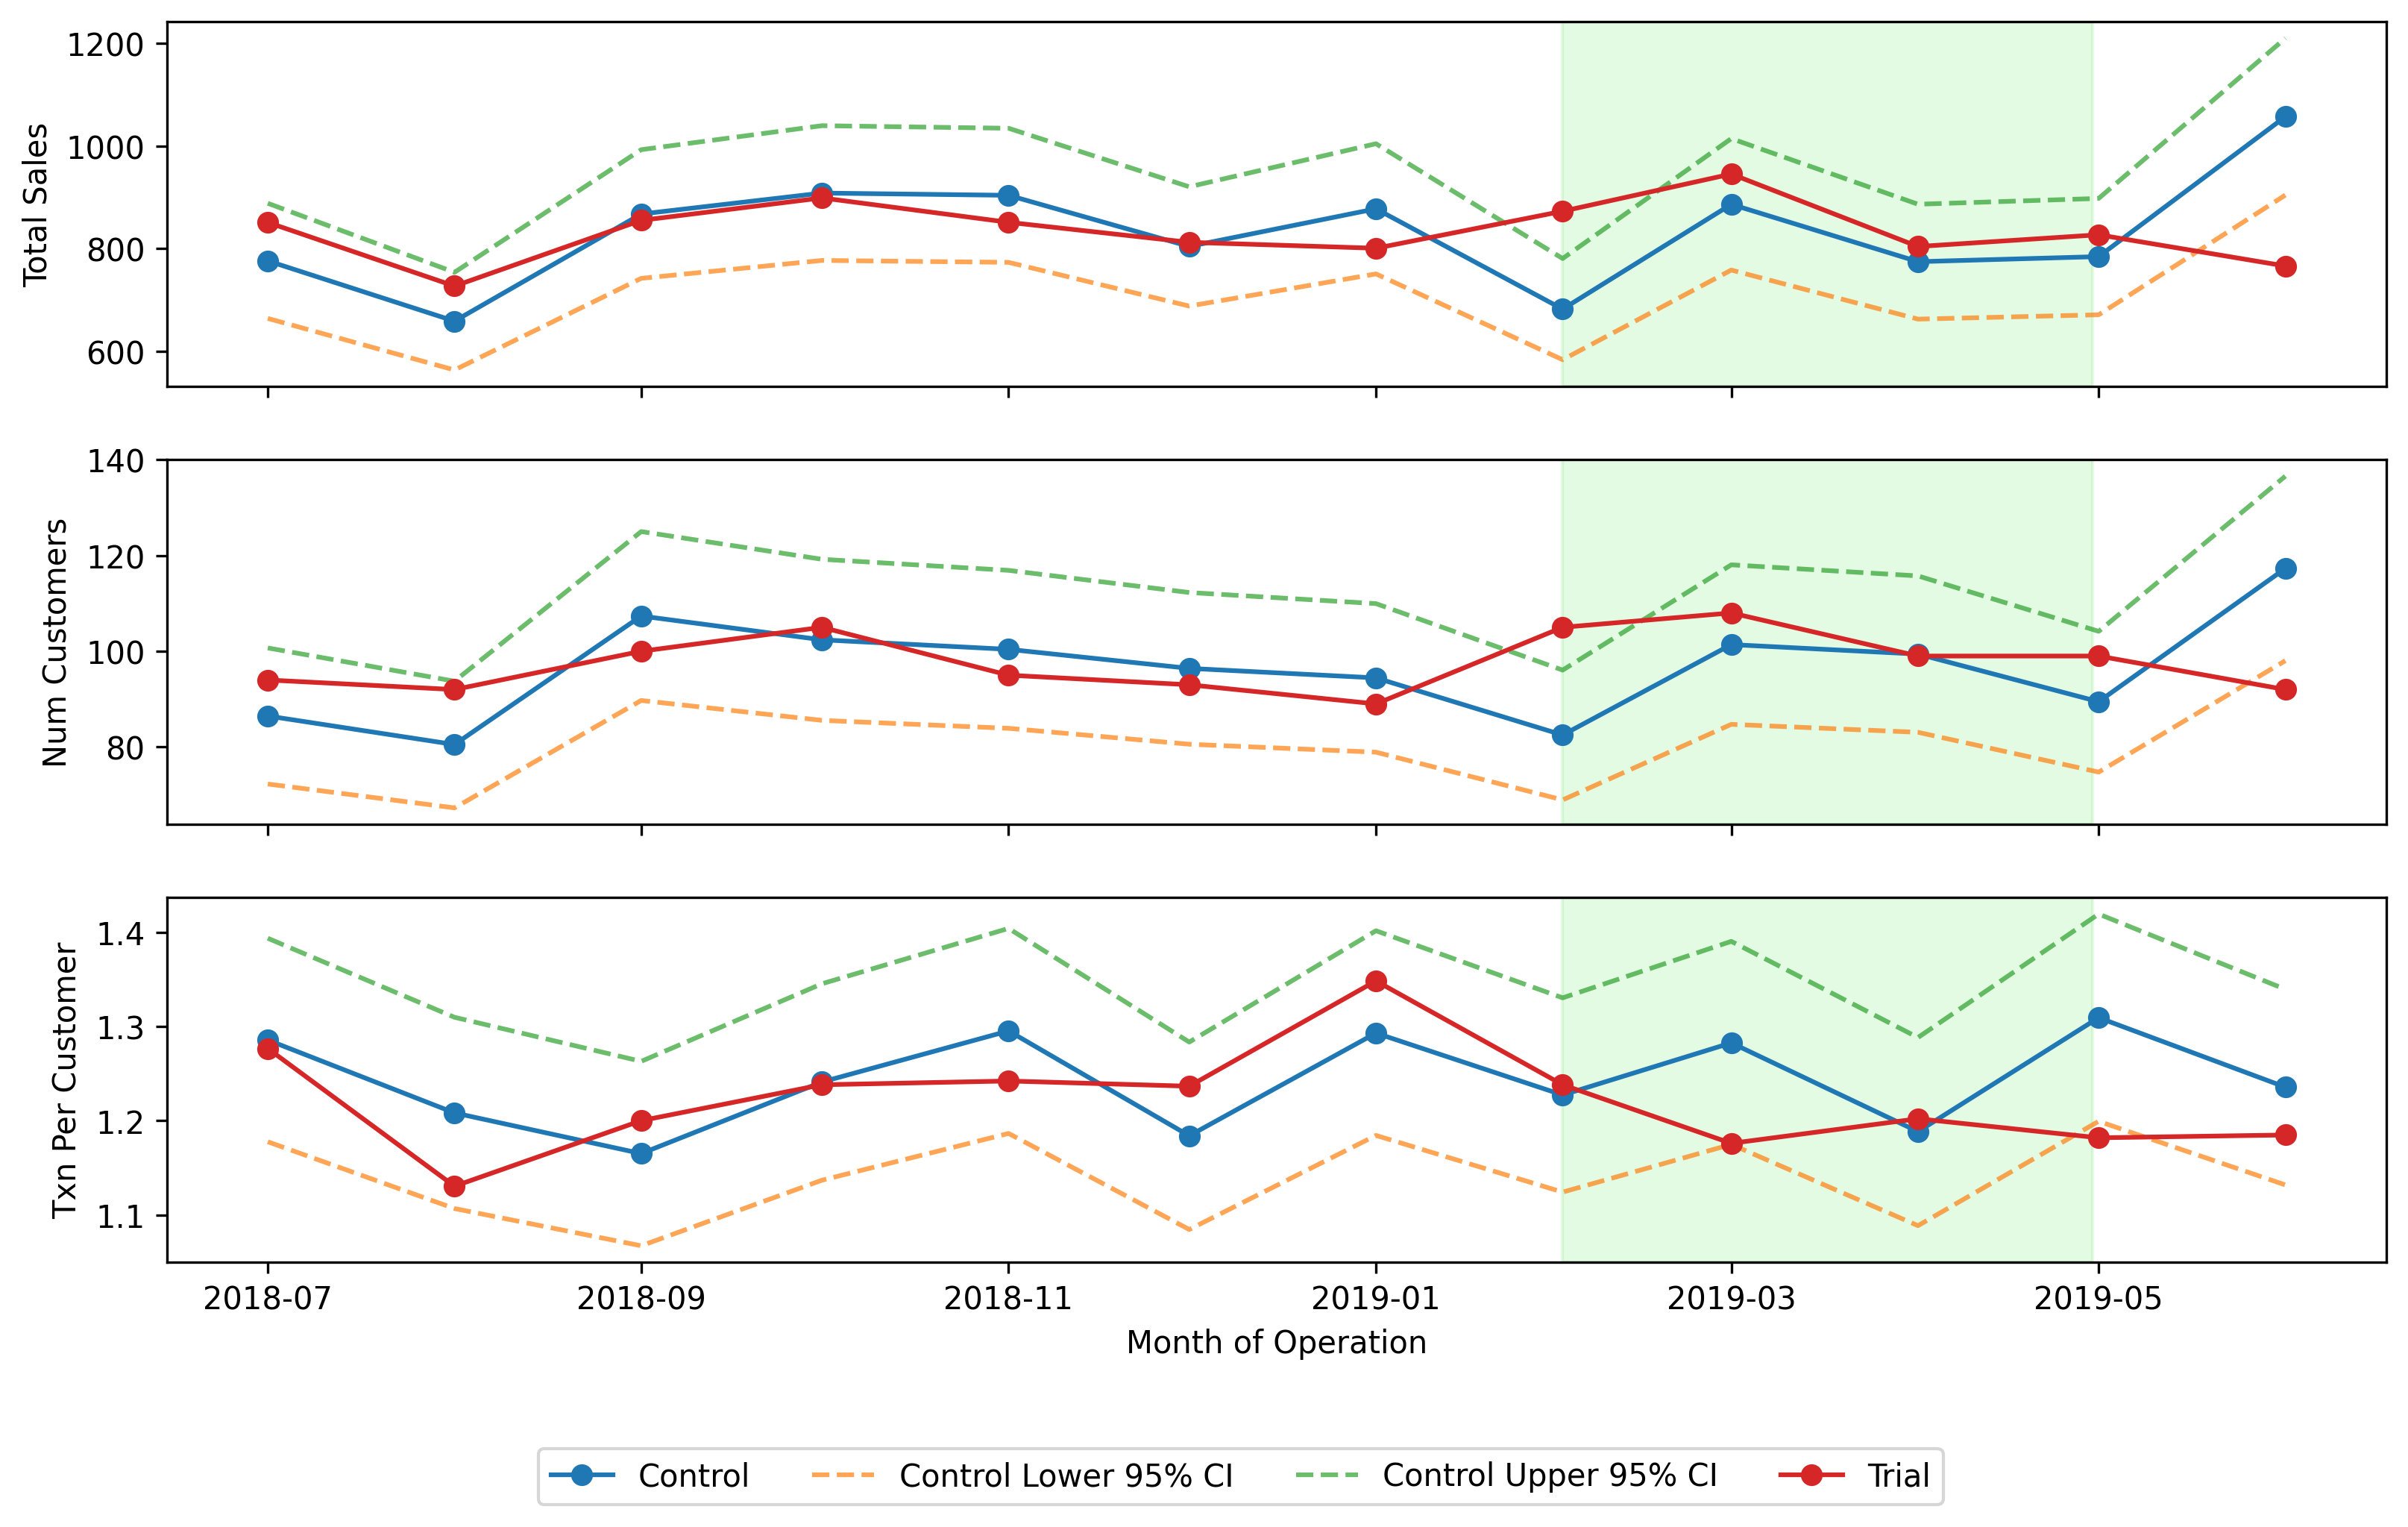

In [116]:
fig, axes = plt.subplots(3, 1, figsize=(12.8, 7.2), sharex=True, dpi=300)

datasets = [
    (store_86_sales_assessment, "total_sales", "Total Sales"),
    (store_86_ncust_assessment, "num_customers", "Number of Customers"),
    (store_86_txn_assessment, "txn_per_customer", "Transactions per Customer")
]

for ax, (df, metric, title) in zip(axes, datasets):
    plot_metric(ax, df, metric, title, trial_start, trial_end)

axes[-1].set_xlabel("Month of Operation")
handles, labels = axes[0].get_legend_handles_labels()

by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4
)

## **UPLIFT ANALYSIS FOR STORE 88**

In [91]:
store88_scaled_sales_control= scaled_control_metric(matched_88_full, 88, store_88['control_store'].iloc[0], 'total_sales')
store88_scaled_sales_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 1001 to 2345
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   YEARMONTH                   24 non-null     int64         
 1   TransactionMonth            24 non-null     datetime64[ns]
 2   STORE_NBR                   24 non-null     int64         
 3   store_type                  24 non-null     object        
 4   total_sales                 24 non-null     float64       
 5   num_customers               24 non-null     int64         
 6   txn_per_customer            24 non-null     float64       
 7   adjusted_total_sales        24 non-null     float64       
 8   scaled_control_total_sales  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [92]:
store88_scaled_sales_control.head(5)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_total_sales,scaled_control_total_sales
1001,201807,2018-07-01,88,Trial,1218.2,124,1.161290,1218.2,NaN
1002,201808,2018-08-01,88,Trial,1242.2,125,1.200000,1242.2,NaN
1003,201809,2018-09-01,88,Trial,1361.8,121,1.247934,1361.8,NaN
1004,201810,2018-10-01,88,Trial,1270.8,120,1.225000,1270.8,NaN
1005,201811,2018-11-01,88,Trial,1311.4,123,1.211382,1311.4,NaN


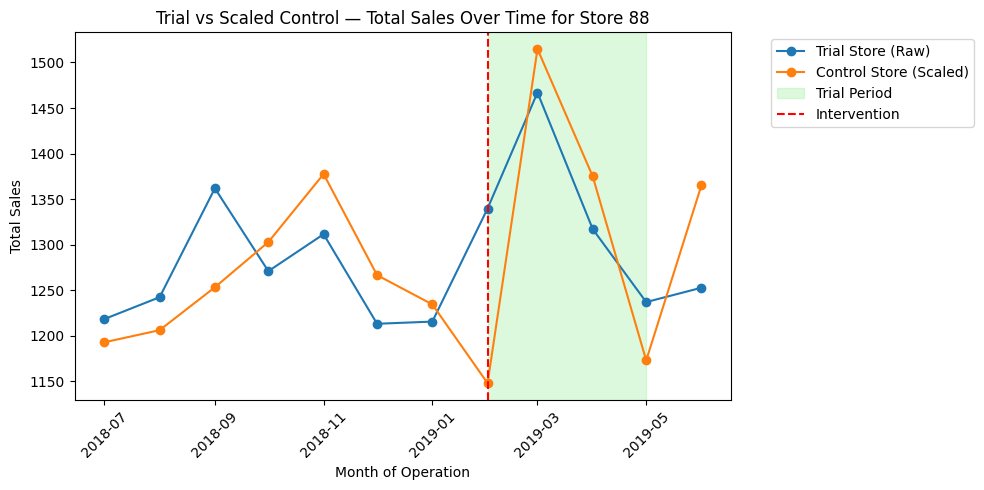

In [93]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store88_scaled_sales_control[
    store88_scaled_sales_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store88_scaled_sales_control[
    store88_scaled_sales_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['total_sales'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_total_sales'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Total Sales")
plt.title("Trial vs Scaled Control — Total Sales Over Time for Store 88")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [94]:
store88_sales_t_comp = t_statistic_comp(matched_88_full, 88, store_88['control_store'].iloc[0], 'total_sales')
print(store88_sales_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  total_sales  scaled_control_total_sales  pct_diff  \
0        2018-07-01      1218.20                 1192.666305  0.021409   
1        2018-08-01      1242.20                 1206.006837  0.030011   
2        2018-09-01      1361.80                 1253.097772  0.086747   
3        2018-10-01      1270.80                 1302.811205 -0.024571   
4        2018-11-01      1311.40                 1377.495376 -0.047982   
5        2018-12-01      1213.00                 1266.438303 -0.042196   
6        2019-01-01      1215.40                 1234.284202 -0.015300   
7        2019-02-01      1339.60                 1147.741781  0.167161   
8        2019-03-01      1467.00                 1514.777425 -0.031541   
9        2019-04-01      1317.00                 1374.872878 -0.042093   
10       2019-05-01      1236.85                 1172.712519  0.054692   
11       2019-06-01      1252.60                 1365.181039 -

In [95]:
store_88_sales_assessment = trial_assessment(matched_88_full, 88, store_88['control_store'].iloc[0], 'total_sales')
store_88_sales_assessment.head(5)

,YEARMONTH,store_type,total_sales,TransactionMonth
0,201807,Trial,1218.2,2018-07-01
1,201808,Trial,1242.2,2018-08-01
2,201809,Trial,1361.8,2018-09-01
3,201810,Trial,1270.8,2018-10-01
4,201811,Trial,1311.4,2018-11-01


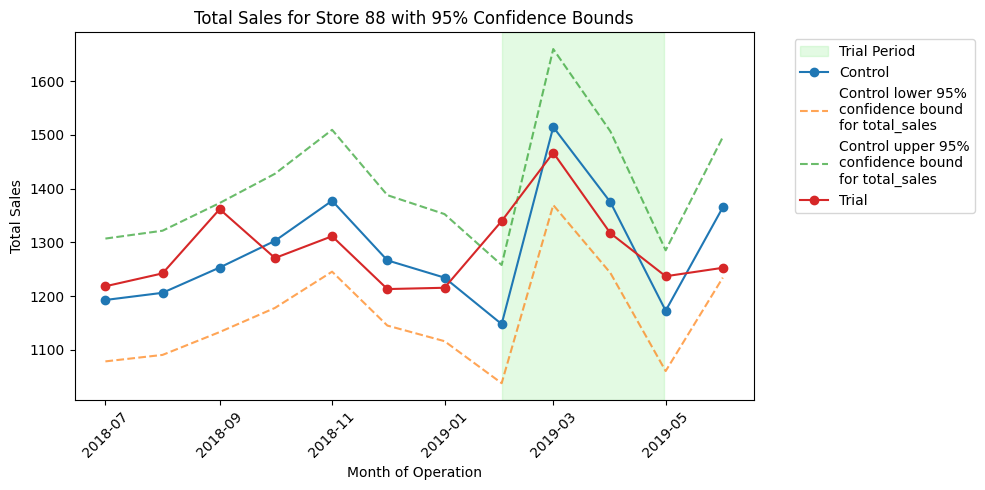

In [96]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_88_sales_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['total_sales'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['total_sales'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Total Sales")
ax.set_title("Total Sales for Store 88 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Total Sales Impact — Store 88**

For Store 88, the control store outperforms the trial store in total sales for most of the trial period, except at the beginning of the trial where the trial store briefly exceeds the control store performance.

Only the first trial month is statistically significant and falls outside the 95% confidence bounds of the control distribution. The remaining months remain within the confidence interval, indicating limited evidence of a sustained positive intervention effect on total sales.

In [97]:
store88_scaled_ncust_control= scaled_control_metric(matched_88_full, 88, store_88['control_store'].iloc[0], 'num_customers')
store88_scaled_ncust_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 1001 to 2345
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   YEARMONTH                     24 non-null     int64         
 1   TransactionMonth              24 non-null     datetime64[ns]
 2   STORE_NBR                     24 non-null     int64         
 3   store_type                    24 non-null     object        
 4   total_sales                   24 non-null     float64       
 5   num_customers                 24 non-null     int64         
 6   txn_per_customer              24 non-null     float64       
 7   adjusted_num_customers        24 non-null     float64       
 8   scaled_control_num_customers  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [98]:
store88_scaled_ncust_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_num_customers,scaled_control_num_customers
1001,201807,2018-07-01,88,Trial,1218.2,124,1.161290,124.0,NaN
1002,201808,2018-08-01,88,Trial,1242.2,125,1.200000,125.0,NaN
1003,201809,2018-09-01,88,Trial,1361.8,121,1.247934,121.0,NaN


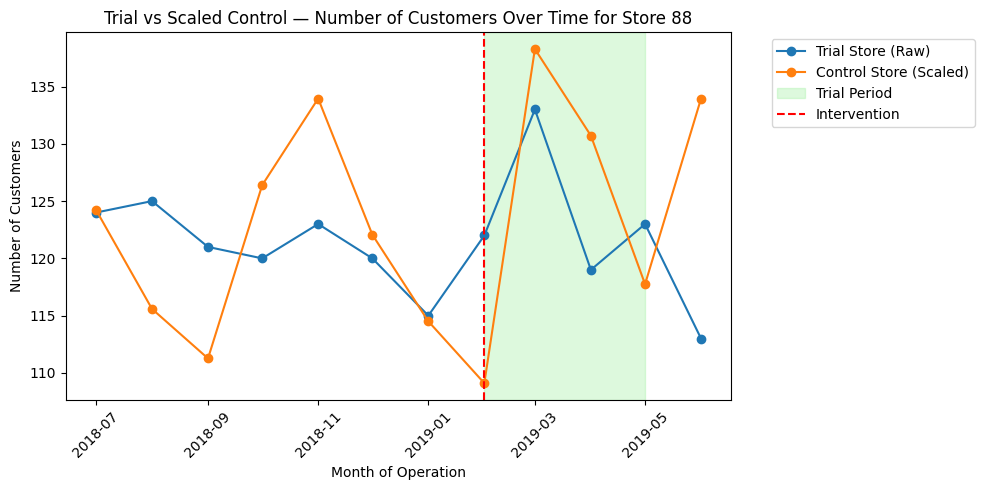

In [99]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store88_scaled_ncust_control[
    store88_scaled_ncust_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store88_scaled_ncust_control[
    store88_scaled_ncust_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['num_customers'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_num_customers'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Number of Customers")
plt.title("Trial vs Scaled Control — Number of Customers Over Time for Store 88")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [100]:
store88_ncust_t_comp = t_statistic_comp(matched_88_full, 88, store_88['control_store'].iloc[0], 'num_customers')
print(store88_ncust_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  num_customers  scaled_control_num_customers  pct_diff  \
0        2018-07-01            124                    124.229299 -0.001846   
1        2018-08-01            125                    115.587261  0.081434   
2        2018-09-01            121                    111.266242  0.087482   
3        2018-10-01            120                    126.389809 -0.050556   
4        2018-11-01            123                    133.951592 -0.081758   
5        2018-12-01            120                    122.068790 -0.016948   
6        2019-01-01            115                    114.507006  0.004305   
7        2019-02-01            122                    109.105732  0.118181   
8        2019-03-01            133                    138.272611 -0.038132   
9        2019-04-01            119                    130.710828 -0.089593   
10       2019-05-01            123                    117.747771  0.044606   
11       2019-

In [101]:
store_88_ncust_assessment = trial_assessment(matched_88_full, 88, store_88['control_store'].iloc[0], 'num_customers')
store_88_ncust_assessment.head(5)

,YEARMONTH,store_type,num_customers,TransactionMonth
0,201807,Trial,124.0,2018-07-01
1,201808,Trial,125.0,2018-08-01
2,201809,Trial,121.0,2018-09-01
3,201810,Trial,120.0,2018-10-01
4,201811,Trial,123.0,2018-11-01


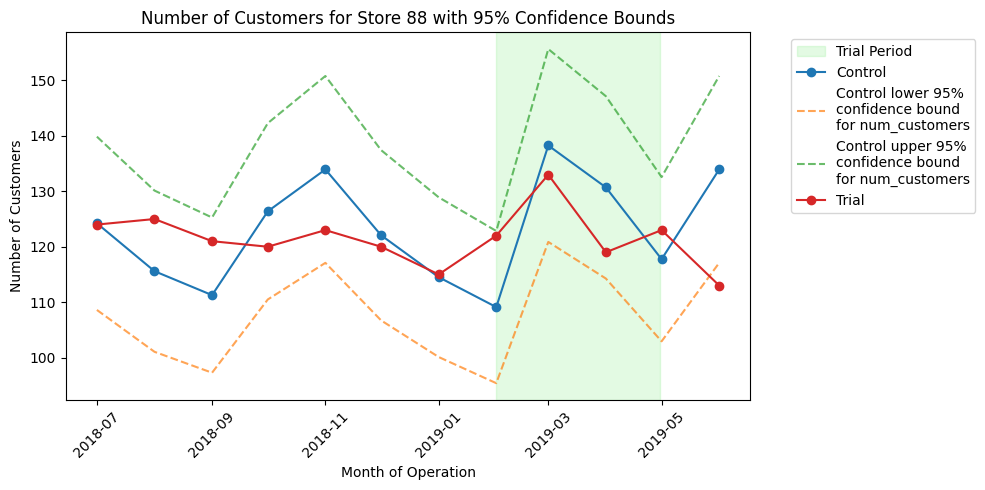

In [102]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_88_ncust_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['num_customers'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['num_customers'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Number of Customers")
ax.set_title("Number of Customers for Store 88 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Customer Count Impact — Store 88**

The number of customers visiting Store 88 rises briefly at the start of the trial period, exceeding the expected level under the counterfactual condition, before falling below the customer count of the control store in subsequent months.

There is no evidence of statistical significance throughout the trial period, as all observations remain within the confidence bounds of the control distribution. This suggests that the observed variation in customer count is consistent with expected baseline fluctuation rather than a sustained intervention effect.


In [103]:
store88_scaled_txn_control= scaled_control_metric(matched_88_full, 88, store_88['control_store'].iloc[0], 'txn_per_customer')
store88_scaled_txn_control.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 1001 to 2345
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   YEARMONTH                        24 non-null     int64         
 1   TransactionMonth                 24 non-null     datetime64[ns]
 2   STORE_NBR                        24 non-null     int64         
 3   store_type                       24 non-null     object        
 4   total_sales                      24 non-null     float64       
 5   num_customers                    24 non-null     int64         
 6   txn_per_customer                 24 non-null     float64       
 7   adjusted_txn_per_customer        24 non-null     float64       
 8   scaled_control_txn_per_customer  12 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 1.9+ KB


In [104]:
store88_scaled_txn_control.head(3)

,YEARMONTH,TransactionMonth,STORE_NBR,store_type,total_sales,num_customers,txn_per_customer,adjusted_txn_per_customer,scaled_control_txn_per_customer
1001,201807,2018-07-01,88,Trial,1218.2,124,1.161290,1.161290,NaN
1002,201808,2018-08-01,88,Trial,1242.2,125,1.200000,1.200000,NaN
1003,201809,2018-09-01,88,Trial,1361.8,121,1.247934,1.247934,NaN


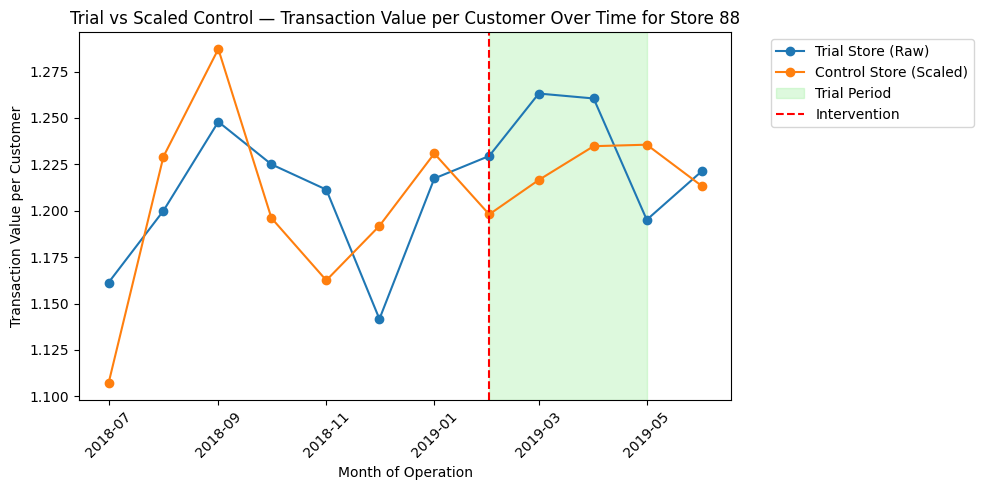

In [105]:
plt.figure(figsize=(10, 5))

# --- Sort data ---
trial = store88_scaled_txn_control[
    store88_scaled_txn_control['store_type'] == 'Trial'
].sort_values('TransactionMonth')

control = store88_scaled_txn_control[
    store88_scaled_txn_control['store_type'] == 'Control'
].sort_values('TransactionMonth')

# --- Plot trial store (raw) ---
plt.plot(
    trial['TransactionMonth'],
    trial['txn_per_customer'],
    marker='o',
    label='Trial Store (Raw)'
)

# --- Plot control store (scaled) ---
plt.plot(
    control['TransactionMonth'],
    control['scaled_control_txn_per_customer'],
    marker='o',
    label='Control Store (Scaled)'
)

# --- Shade trial period only (2019-02 to 2019-04) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-05-01")

plt.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.3,
    label='Trial Period'
)

# --- Intervention line ---
intervention_date = pd.to_datetime("2019-02-01")
plt.axvline(
    x=intervention_date,
    color='red',
    linestyle='--',
    label='Intervention'
)

# --- Labels and title ---
plt.xlabel("Month of Operation")
plt.ylabel("Transaction Value per Customer")
plt.title("Trial vs Scaled Control — Transaction Value per Customer Over Time for Store 88")

# --- Legend ---
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [106]:
store88_txn_t_comp = t_statistic_comp(matched_88_full, 88, store_88['control_store'].iloc[0], 'txn_per_customer')
print(store88_txn_t_comp)

The critical t-value for 95% confidence is: 1.943
   TransactionMonth  txn_per_customer  scaled_control_txn_per_customer  \
0        2018-07-01          1.161290                         1.107078   
1        2018-08-01          1.200000                         1.229184   
2        2018-09-01          1.247934                         1.287135   
3        2018-10-01          1.225000                         1.196070   
4        2018-11-01          1.211382                         1.162491   
5        2018-12-01          1.141667                         1.191852   
6        2019-01-01          1.217391                         1.230854   
7        2019-02-01          1.229508                         1.198029   
8        2019-03-01          1.263158                         1.216585   
9        2019-04-01          1.260504                         1.234792   
10       2019-05-01          1.195122                         1.235590   
11       2019-06-01          1.221239                         

In [107]:
store_88_txn_assessment = trial_assessment(matched_88_full, 88, store_88['control_store'].iloc[0], 'txn_per_customer')
store_88_txn_assessment.head(5)

,YEARMONTH,store_type,txn_per_customer,TransactionMonth
0,201807,Trial,1.161290,2018-07-01
1,201808,Trial,1.200000,2018-08-01
2,201809,Trial,1.247934,2018-09-01
3,201810,Trial,1.225000,2018-10-01
4,201811,Trial,1.211382,2018-11-01


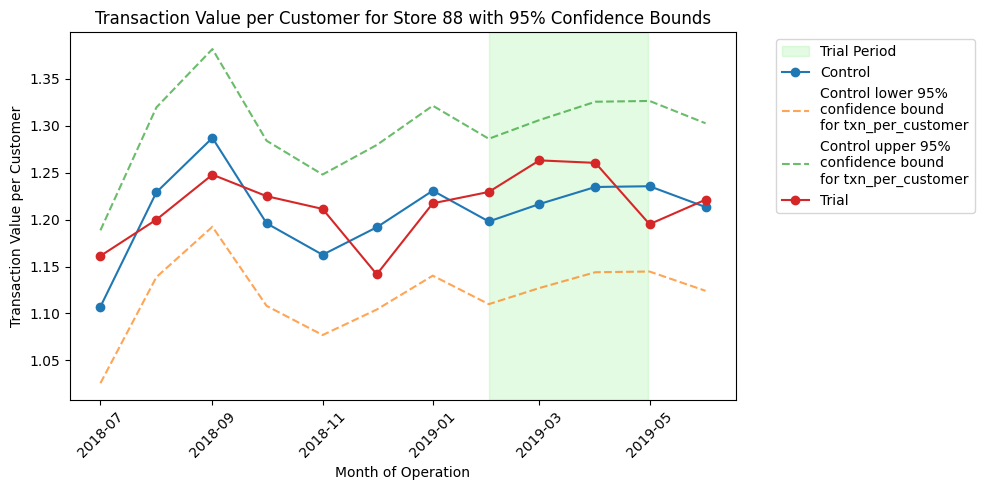

In [108]:
fig, ax = plt.subplots(figsize=(10, 5))

# --- Define trial period (201902–201904) ---
trial_start = pd.to_datetime("2019-02-01")
trial_end   = pd.to_datetime("2019-04-30")

# --- Shade trial period only ---
ax.axvspan(
    trial_start,
    trial_end,
    color='lightgreen',
    alpha=0.25,
    label='Trial Period'
)

# --- Plot each store type (trial, control, upper, lower) ---
for key, grp in store_88_txn_assessment.groupby('store_type'):
    grp = grp.sort_values('TransactionMonth')

    # Confidence bounds should be dashed
    if "upper" in key.lower() or "lower" in key.lower():
        ax.plot(
            grp['TransactionMonth'],
            grp['txn_per_customer'],
            linestyle='--',
            alpha=0.7,
            label=key
        )
    else:
        # Trial + Control lines
        ax.plot(
            grp['TransactionMonth'],
            grp['txn_per_customer'],
            marker='o',
            label=key
        )

# --- Labels and title ---
ax.set_xlabel("Month of Operation")
ax.set_ylabel("Transaction Value per Customer")
ax.set_title("Transaction Value per Customer for Store 88 with 95% Confidence Bounds")

# --- Legend ---
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Transactions per Customer Impact — Store 88**

Transactions per customer in Store 88 show a consistent increase during the trial period relative to the control store. However, the observed differences are not statistically significant.

In addition, the control store values remain entirely within, and close to the center of, the confidence bounds throughout the trial period. This indicates that the observed uplift in transaction frequency is within the expected range of baseline variation and does not provide strong evidence of a meaningful intervention effect.


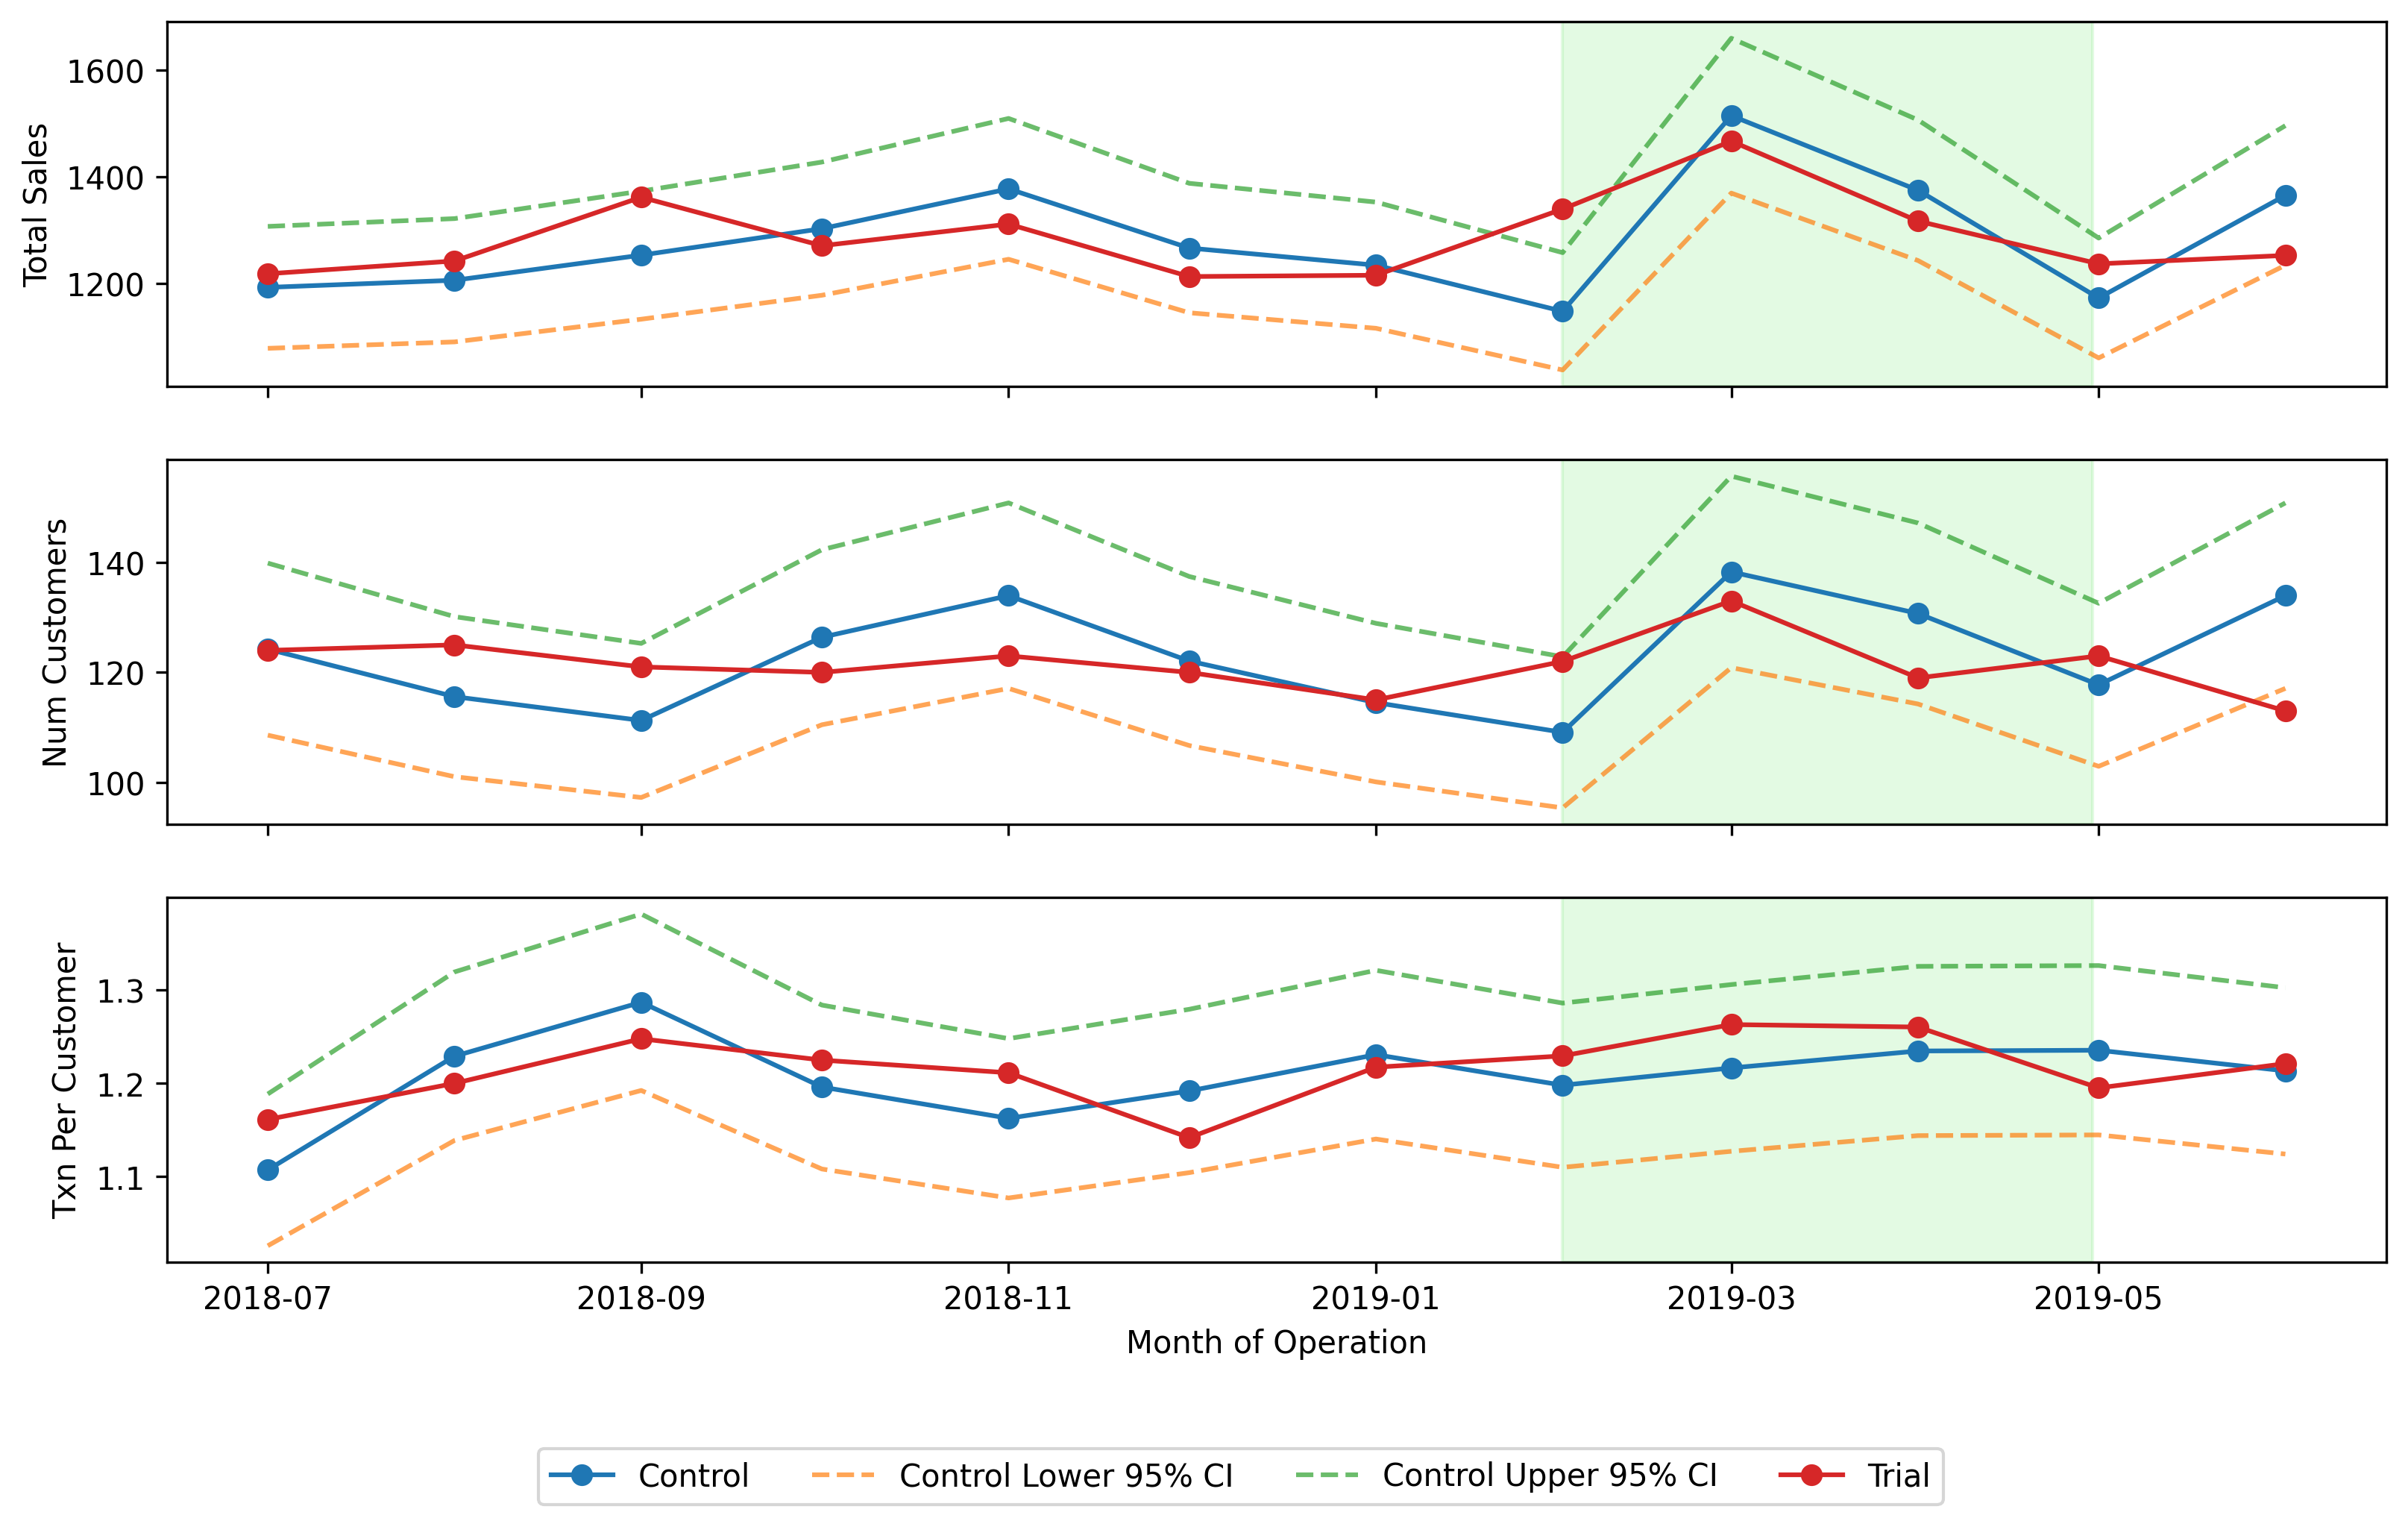

In [117]:
fig, axes = plt.subplots(3, 1, figsize=(12.8, 7.2), sharex=True, dpi=300)

datasets = [
    (store_88_sales_assessment, "total_sales", "Total Sales"),
    (store_88_ncust_assessment, "num_customers", "Number of Customers"),
    (store_88_txn_assessment, "txn_per_customer", "Transactions per Customer")
]

for ax, (df, metric, title) in zip(axes, datasets):
    plot_metric(ax, df, metric, title, trial_start, trial_end)

axes[-1].set_xlabel("Month of Operation")
handles, labels = axes[0].get_legend_handles_labels()

by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4
)

## **OVERALL CONCLUSION AND RECOMMENDATION**
The trial results indicate that the impact of the new store layout varies across stores.

Store 77 shows the strongest evidence of a positive intervention effect, with statistically significant uplift in both total sales and customer count during the trial period. The results suggest that the layout change was effective in increasing customer traffic, which in turn contributed to higher sales performance.

Store 86 exhibits moderate positive uplift across several metrics, although the effect is not consistently statistically significant throughout the trial period. This suggests a possible positive impact, but with weaker supporting evidence relative to Store 77.

In contrast, Store 88 shows limited evidence of sustained improvement. Most observed differences remain within the expected range of baseline variation, indicating that the intervention effect is either weak or inconsistent for this store.

Overall, the results suggest that the new layout has the potential to improve store performance, but the effect is not uniform across locations. A broader rollout should therefore be approached cautiously. Further testing across additional stores and longer observation periods may help determine the conditions under which the layout performs most effectively.